In [ ]:
from collections import defaultdict
import pathlib

In [ ]:
# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import igraph as ig
import iplotx
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-30T00:13:02.127313+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

pandas    : 2.2.3
seaborn   : 0.13.2
requests  : 2.34.2
matplotlib: 3.10.7
marimo    : 0.23.2
iplotx    : 1.7.1
numpy     : 2.1.2
igraph    : 0.11.9
teeplot   : 1.4.2

```

# Community Assembly Graphs

This notebook builds **community assembly graphs** that summarize how
the set of co-circulating strains turns over during each simulation
replicate, then aggregates those per-replicate *transition sequences*
into one directed graph **per mutation rate**.

Each strain is a 3-bit genome (`N_SITES = 3`, so 8 possible strains
`000`..`111`). A **community** (graph node) is the set of strains
simultaneously *present*. As strains are introduced and go extinct,
the community changes; each change is a directed **transition** (edge)
from one community to the next. The founder/wildtype is the all-zero
`000` strain and its bitwise complement is the all-ones `111` strain.

The work is performed in five sections:

1. **Setup / Download** --- pull the three OSF parquet caches.
2. **Build Transition Sequence Graphs per Replicate** --- presence
   calling, per-replicate allele relabeling, end-state cutoff.
3. **Plot the example transition sequence graph for each replicate
   uid** in the example parquet.
4. **Combine Graphs per mutation rate and calculate weightings.**
5. **Plot graphs for each mutation rate** with `iplotx`
   (matplotlib backend) via `teeplot`.

## 1. Setup / Download

Three OSF parquet slugs back this notebook, each downloaded with
`requests` and cached under `/tmp/<slug>` so re-runs hit the local
copy:

- **main** (`wubva`) --- per-`(replicate, strain)` **presence-episode
  event log**. Each episode that a strain spends continuously present
  emits milestone rows at `continuous_steps` = 10, 30, 100, 300 (those
  it reaches) and a terminal `extinct=True` row when the episode ends.
  The persistence threshold is therefore already encoded in
  `continuous_steps`; we use the **300-step** threshold for calling
  introductions/extinctions (not 10, 30, or 100). An `extinct=True`
  row at a step *before* the final step is a genuine extinction; one
  at the final step is right-censoring (the strain is still present).
- **dominant** (`nmzrj`) --- final-step (`Step == n_steps - 1`)
  per-strain case counts, used to identify each replicate's
  end-dominant strain and to test the convergence (>50% prevalence)
  criterion.
- **examples** (`f4bzv`) --- a curated subset of `replicate_uid`s
  (a few per mutation rate) whose individual transition sequences are
  drawn in Section 3.

In [ ]:
# CLI args; defaults pull the parquet caches that back this notebook.
_args = mo.cli_args()
MAIN_SLUG = str(_args.get("main-slug") or "wubva")
DOM_SLUG = str(_args.get("dominant-slug") or "nmzrj")
EX_SLUG = str(_args.get("examples-slug") or "f4bzv")
# persistence threshold (days/steps) for introduction & extinction
# calling; the main parquet encodes 10/30/100/300 --- we use 300.
THRESHOLD = int(_args.get("threshold") or 300)
print(
    f"args: MAIN_SLUG={MAIN_SLUG} DOM_SLUG={DOM_SLUG} "
    f"EX_SLUG={EX_SLUG} THRESHOLD={THRESHOLD}",
)

args: MAIN_SLUG=wubva DOM_SLUG=nmzrj EX_SLUG=f4bzv THRESHOLD=300


In [ ]:
def download_parquet(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=180)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_parquet(cache_path)

In [ ]:
main_df = download_parquet(MAIN_SLUG)
dom_df = download_parquet(DOM_SLUG)
ex_df = download_parquet(EX_SLUG)

N_SITES = int(main_df["n_sites"].iloc[0])
FULL = (1 << N_SITES) - 1  # all-ones strain (complement of wildtype)
N_STEPS = int(main_df["n_steps"].iloc[0])
print(
    f"main: {main_df.shape}  dominant: {dom_df.shape}  ex: {ex_df.shape}"
)
print(f"N_SITES={N_SITES} FULL={FULL:0{N_SITES}b} N_STEPS={N_STEPS}")
print(
    "replicates per mutation_rate:\n"
    + str(main_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

downloading https://osf.io/wubva/download -> /tmp/wubva
size: 4310348 bytes
reusing cached /tmp/nmzrj
size: 575169 bytes
reusing cached /tmp/f4bzv
size: 32413059 bytes
main: (387106, 25)  dominant: (27056, 23)  ex: (2680000, 23)
N_SITES=3 FULL=111 N_STEPS=5000
replicates per mutation_rate:
mutation_rate
1.000000e-09    200
3.000000e-09    199
1.000000e-08    194
3.000000e-08    200
1.000000e-07    196
               ... 
1.000000e-03    200
3.000000e-03    200
1.000000e-02    198
3.000000e-02    200
1.000000e-01    200
Name: replicate_uid, Length: 17, dtype: int64


In [ ]:
pd.concat(
    [
        main_df[
            [
                "replicate_uid",
                "Step",
                "strain",
                "n_cases",
                "count",
                "continuous_steps",
                "extinct",
                "mutation_rate",
            ]
        ].head(),
        main_df[
            [
                "replicate_uid",
                "Step",
                "strain",
                "n_cases",
                "count",
                "continuous_steps",
                "extinct",
                "mutation_rate",
            ]
        ].tail(),
    ],
)

,replicate_uid,Step,strain,n_cases,count,continuous_steps,extinct,mutation_rate
0,0000fc0bd88e4d1fb9ba657562552b42,9,0,7,0.000007,10,False,0.00001
1,0000fc0bd88e4d1fb9ba657562552b42,29,0,417,0.000417,30,False,0.00001
2,0000fc0bd88e4d1fb9ba657562552b42,99,0,72134,0.072134,100,False,0.00001
3,0000fc0bd88e4d1fb9ba657562552b42,299,0,9329,0.009329,300,False,0.00001
4,0000fc0bd88e4d1fb9ba657562552b42,4999,0,120,0.000120,5000,True,0.00001
387101,ffd24fcf37e345c5bd12b4914e7762d7,9,7,1,0.000001,10,False,0.03000
387102,ffd24fcf37e345c5bd12b4914e7762d7,29,7,23,0.000023,30,False,0.03000
387103,ffd24fcf37e345c5bd12b4914e7762d7,99,7,28131,0.028131,100,False,0.03000
387104,ffd24fcf37e345c5bd12b4914e7762d7,299,7,13203,0.013203,300,False,0.03000
387105,ffd24fcf37e345c5bd12b4914e7762d7,4999,7,12951,0.012951,5000,True,0.03000


## 2. Build Transition Sequence Graphs per Replicate

For each replicate we reconstruct the ordered sequence of community
states (the *transition sequence*) from the presence-episode log.

**Presence calling (300-step threshold).** Walking each strain's rows
in time order, episodes are delimited by `extinct=True` rows. An
episode counts as a real *introduction* only if it reaches
`continuous_steps >= THRESHOLD` (briefer blips are dropped). The
strain is then *present* from the step at which it crossed the
threshold until its episode's terminal `extinct=True` row. A terminal
row at the final step (`Step >= N_STEPS - 1`) is right-censored ---
the strain is still present at the end --- whereas an earlier terminal
row is a genuine extinction.

**Per-replicate allele relabeling.** Bit positions (sites) are
reordered so the site whose mutant allele *appears first* (earliest
introduction of any strain carrying it) occupies position 0, the
second-to-appear position 1, and the third position 2. Every strain
label in the replicate is permuted accordingly. The wildtype `000`
and its complement `111` are fixed points of any such permutation.

**End-state cutoff.** Let `D` be the replicate's end-dominant strain
(largest final-step count) and `comp = D ^ FULL` its complement. A
replicate **converges** when `D` and `comp` both appear *and* together
they exceed 50% of circulating cases. Because the main log records
prevalence only at early episode milestones, the >50% test is applied
to the accurate **final-step** relative prevalence
`(count_D + count_comp) / total_cases` (from the dominant parquet);
the sequence is then cut off one community past the first in which both
`D` and `comp` are present --- keeping that first co-occurrence
community so the one the complement arose in is shown --- before
transitioning to the complement-pair end node. Replicates that **fail
to converge** terminate in a special end node labelled **`U`**.

In [ ]:
# Per-replicate: end-dominant strain D, its complement, and whether
# the run converged (final-step relative prevalence of D+comp > 0.5).
def build_conv_info(dom_df):
    info = {}
    for uid, sub in dom_df.groupby("replicate_uid"):
        counts = sub.set_index("strain")["count"]
        total = float(counts.sum())
        D = int(counts.idxmax())
        comp = D ^ FULL
        rel = (
            (counts.get(D, 0.0) + counts.get(comp, 0.0)) / total
            if total > 0
            else 0.0
        )
        info[uid] = {"D": D, "comp": comp, "converged": bool(rel > 0.5)}
    return info

conv_info = build_conv_info(dom_df)
_n_conv = sum(v["converged"] for v in conv_info.values())
print(
    f"convergence (final D+comp > 50% of cases): "
    f"{_n_conv} / {len(conv_info)} replicates",
)

convergence (final D+comp > 50% of cases): 2368 / 3382 replicates


In [ ]:
def build_intervals(rep_df):
    """Presence intervals for episodes reaching THRESHOLD.

    Returns list of (strain, intro_step, ext_step). ``ext_step ==
    N_STEPS`` marks a right-censored episode (present through the
    final step); otherwise it is the extinction step.
    """
    out = []
    for s, sdf in rep_df.groupby("strain"):
        sdf = sdf.sort_values("Step")
        episode = []
        for row in sdf.itertuples(index=False):
            episode.append(row)
            if row.extinct:
                reached = max(x.continuous_steps for x in episode)
                if reached >= THRESHOLD:
                    intro = next(
                        x
                        for x in episode
                        if x.continuous_steps >= THRESHOLD
                    )
                    term = episode[-1]
                    ext = (
                        N_STEPS
                        if term.Step >= N_STEPS - 1
                        else int(term.Step)
                    )
                    out.append((int(s), int(intro.Step), ext))
                episode = []
    return out

def relabel_fn(intervals):
    """Bit permutation ordering sites by first-appearance step."""
    first = {i: np.inf for i in range(N_SITES)}
    for strain, intro, _ext in intervals:
        for i in range(N_SITES):
            if (strain >> i) & 1:
                first[i] = min(first[i], intro)
    order = sorted(range(N_SITES), key=lambda i: (first[i], i))
    perm = {order[k]: k for k in range(N_SITES)}
    return lambda x: sum(
        (1 << perm[i]) for i in range(N_SITES) if (x >> i) & 1
    )

In [ ]:
def binstr(strain):
    return format(strain, f"0{N_SITES}b")

def pair_key(a, b):
    """Canonical label for a complement-pair end node, e.g. 000/111."""
    lo, hi = sorted((a, b))
    return f"{binstr(lo)}/{binstr(hi)}"

# Special end nodes (drawn like the U node): one per complement pair
# for converged runs, plus U for runs that fail to converge. The
# 000/111 pair (wildtype + all-ones) is outlined green and U red; the
# remaining pairs get their own distinct outline colors.
PAIR_KEYS = [
    pair_key(s, s ^ FULL) for s in range(FULL + 1) if s <= s ^ FULL
]
_pair_palette = ["green", "#1f77b4", "#ff7f0e", "#9467bd", "#8c564b"]
END_OUTLINE = {pk: _pair_palette[i] for i, pk in enumerate(PAIR_KEYS)}
END_OUTLINE["000/111"] = "green"
END_OUTLINE["U"] = "red"

def is_end_key(key):
    """Special end node (complement pair or U) vs. transient community."""
    return isinstance(key, str)

def edge_delta_label(a, b):
    """Strain-level transition label, e.g. "+100" (introduced) or
    "-010" (went extinct); "" for transitions into a special end
    node (complement-pair collapse or non-convergence), which are
    not single-strain events.
    """
    if is_end_key(a) or is_end_key(b):
        return ""
    parts = [f"+{binstr(s)}" for s in sorted(b - a)]
    parts += [f"-{binstr(s)}" for s in sorted(a - b)]
    return ",".join(parts)

def assemble(uid, rep_df):
    """Build a replicate's transition sequence.

    Returns ``(path, converged, pair)``. ``path`` is the list of
    relabeled ``frozenset`` community states (all transient). For a
    converged run, ``pair`` is the complement-pair end-node label and
    ``path`` is cut off one past the dominant strain and its complement
    first co-occurring (keeping that community, so the one the
    complement arose in is shown); the caller appends ``pair`` as the
    terminal end node. A non-converging run has ``pair is None`` and
    the caller appends ``"U"`` instead.
    """
    intervals = build_intervals(rep_df)
    remap = relabel_fn(intervals)
    D = conv_info[uid]["D"]
    comp = conv_info[uid]["comp"]
    converged_run = conv_info[uid]["converged"]

    events = defaultdict(list)
    for strain, intro, ext in intervals:
        events[intro].append((1, strain))
        if ext < N_STEPS:
            events[ext].append((0, strain))

    present = set()
    seq = []
    for step in sorted(events):
        for kind, strain in events[step]:
            if kind:
                present.add(strain)
            else:
                present.discard(strain)
        ps = frozenset(present)
        if not ps and not seq:
            continue
        if seq and seq[-1] == ps:
            continue
        seq.append(ps)

    # Every run is seeded with the 000 wildtype present, so the
    # transition sequence always begins at the {000} founder node
    # (relabeling leaves 000 fixed). Prepend it when the threshold
    # dynamics don't already start there (e.g. at high mutation rate,
    # where the founder's first episode can blip out before the
    # 30-step threshold while a complement strain establishes).
    founder = frozenset({0})
    if not seq or seq[0] != founder:
        seq = [founder] + seq

    # Cut off once the end-dominant strain and its complement have both
    # appeared, keeping that first co-occurrence community (one past the
    # complement's arrival) so the community the complement arose in is
    # visible; the converged outcome then collapses into a complement-
    # pair end node.
    converged = False
    pair = None
    if converged_run:
        for idx, ps in enumerate(seq):
            if D in ps and comp in ps:
                seq = seq[: idx + 1]
                converged = True
                pair = pair_key(remap(D), remap(comp))
                break

    path = [frozenset(remap(s) for s in ps) for ps in seq]
    return path, converged, pair

def path_with_end(uid, rep_df):
    path, converged, pair = assemble(uid, rep_df)
    keys = list(path)
    keys.append(pair if converged else "U")
    return keys, converged

def node_text(key):
    if key == "U":
        return "U  (failed to converge)"
    if is_end_key(key):
        return f"{key}  (converged pair)"
    return ", ".join(binstr(s) for s in sorted(key))

def node_count_label(key):
    # Number of strains present (complement-pair end nodes hold 2).
    if key == "U":
        return "U"
    if is_end_key(key):
        return "2"
    return str(len(key))

In [ ]:
# Sanity peek: a handful of example replicate sequences.
_uids = ex_df["replicate_uid"].unique()[:6]
for _uid in _uids:
    _keys, _conv = path_with_end(
        _uid, main_df[main_df["replicate_uid"] == _uid]
    )
    _mu = main_df.loc[
        main_df["replicate_uid"] == _uid, "mutation_rate"
    ].iloc[0]
    print(f"{_uid[:8]} mu={_mu:.0e} converged={_conv}")
    print("   " + " -> ".join("[" + node_text(k) + "]" for k in _keys))

a89483e6 mu=1e-01 converged=False
   [000] -> [111] -> [000, 111] -> [000, 101, 111] -> [000, 010, 101, 110, 111] -> [000, 010, 011, 101, 110, 111] -> [000, 010, 011, 100, 101, 110, 111] -> [000, 001, 010, 011, 100, 101, 110, 111] -> [U  (failed to converge)]
e05eea5c mu=1e-02 converged=False
   [000] -> [001, 010] -> [001, 010, 011] -> [001, 010, 011, 111] -> [001, 010, 011, 101, 111] -> [000, 001, 010, 011, 101, 111] -> [000, 001, 010, 011, 101, 110, 111] -> [000, 001, 010, 011, 100, 101, 110, 111] -> [U  (failed to converge)]
d6d96e3b mu=1e-02 converged=False
   [000] -> [000, 011] -> [000, 001, 011] -> [000, 001, 011, 110, 111] -> [000, 001, 010, 011, 110, 111] -> [000, 001, 010, 011, 100, 101, 110, 111] -> [U  (failed to converge)]
51921f05 mu=1e-01 converged=False
   [000] -> [111] -> [000, 111] -> [000, 100, 111] -> [000, 011, 100, 111] -> [000, 011, 100, 101, 111] -> [000, 010, 011, 100, 101, 111] -> [000, 001, 010, 011, 100, 101, 111] -> [000, 001, 010, 011, 100, 101, 110, 111

## 3. Example Transition Sequence Graph per Replicate

For every `replicate_uid` in the examples parquet we draw its
individual transition sequence as a left-to-right directed path, one
figure per mutation rate (each row is one replicate). Nodes are
color-coded by their community (present-strain set) via the key on
the right; the **number on each node is the count of present
strains**. Each run terminates in a **special end node** drawn white
(like the `U` node): a converged run lands on the **complement-pair**
node it converged to (`000/111`, `001/110`, `010/101`, `011/100`),
while a non-converging run terminates in **`U`**. The `000/111` pair
(wildtype + all-ones) is outlined **green** and `U` is outlined
**red**; the other pairs get their own outline colors. Edges between
transient communities are labelled with the strain that was
introduced (`+100`) or went extinct (`-010`) in that transition; the
final edge into a special end node is left unlabelled.

In [ ]:
def node_colormap(allsets, palette="husl"):
    # Color only transient community nodes; special end nodes (pairs
    # and U) are drawn white with a colored outline.
    ordered = sorted(
        (s for s in allsets if not is_end_key(s)),
        key=lambda s: (len(s), tuple(sorted(s))),
    )
    colors = sns.color_palette(palette, n_colors=max(3, len(ordered)))
    return {k: colors[i] for i, k in enumerate(ordered)}

def plot_path(keys, converged, ax, colormap):
    n = len(keys)
    g = ig.Graph(directed=True)
    g.add_vertices(n)
    g.add_edges([(i, i + 1) for i in range(n - 1)])
    coords = [(float(i), 0.0) for i in range(n)]
    vface, vedge, vlw, vlabel, vsize = [], [], [], [], []
    for j, k in enumerate(keys):
        last = j == n - 1
        if is_end_key(k):
            vface.append("white")
            vedge.append(END_OUTLINE.get(k, "black"))
            vlw.append(3.0)
        else:
            vface.append(colormap[k])
            vedge.append("black")
            vlw.append(1.0)
        vlabel.append(node_count_label(k))
        vsize.append(34.0 if last else 26.0)
    elabel = [edge_delta_label(keys[i], keys[i + 1]) for i in range(n - 1)]
    iplotx.network(
        g,
        layout=coords,
        vertex_labels=vlabel,
        edge_labels=elabel,
        ax=ax,
        vertex_facecolor=vface,
        vertex_edgecolor=vedge,
        vertex_size=vsize,
        vertex_linewidth=vlw,
        edge_linewidth=2.0,
        edge_color="0.55",
        vertex_label_color="black",
        vertex_label_size=9,
        edge_label_size=7,
        edge_label_rotate=False,
        show=False,
    )
    ax.margins(0.15)

def path_legend(ax, colormap, allsets):
    ax.axis("off")
    communities = sorted(
        (s for s in allsets if not is_end_key(s)),
        key=lambda s: (len(s), tuple(sorted(s))),
    )
    ends = sorted(s for s in allsets if is_end_key(s) and s != "U")
    if "U" in allsets:
        ends.append("U")
    handles, labels = [], []
    for k in communities:
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=colormap[k],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=9,
            )
        )
        labels.append(node_text(k))
    for k in ends:
        outline = END_OUTLINE.get(k, "black")
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="white",
                markeredgecolor=outline,
                markeredgewidth=2.0,
                markersize=9,
            )
        )
        labels.append(node_text(k))
    ax.legend(
        handles,
        labels,
        loc="center left",
        fontsize=6.5,
        title="community (present strains)",
        title_fontsize=8,
        ncol=1 if len(handles) < 16 else 2,
        frameon=False,
        labelspacing=0.3,
        handletextpad=0.4,
        borderaxespad=0.0,
    )

In [ ]:
def plot_examples_for_mu(mu, uids, main_df):
    paths = []
    for uid in uids:
        keys, conv = path_with_end(
            uid, main_df[main_df["replicate_uid"] == uid]
        )
        paths.append((uid, keys, conv))
    allsets = {k for _u, ks, _c in paths for k in ks}
    colormap = node_colormap(allsets)
    nrow = max(1, len(paths))

    def _factory(**kwargs):
        fig = plt.figure(**kwargs)
        gs = fig.add_gridspec(nrow, 2, width_ratios=[3, 1.4])
        axes = [fig.add_subplot(gs[i, 0]) for i in range(nrow)]
        lax = fig.add_subplot(gs[:, 1])
        return fig, (axes, lax)

    with tp.teed(
        _factory,
        figsize=(12, 1.5 * nrow + 1.2),
        teeplot_outattrs={
            "a": "example-transition-sequences",
            "mutation-rate": f"{mu:.0e}",
        },
        teeplot_outexclude="viz",
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, (axes, lax)):
        for ax, (uid, keys, conv) in zip(axes, paths):
            plot_path(keys, conv, ax, colormap)
            ax.set_ylabel(
                uid[:6],
                rotation=0,
                ha="right",
                va="center",
                fontsize=7,
            )
        path_legend(lax, colormap, allsets)
        fig.suptitle(
            f"example transition sequences  ---  mutation rate "
            f"= {mu:.0e}",
            fontsize=10,
        )

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-09+ext=.png


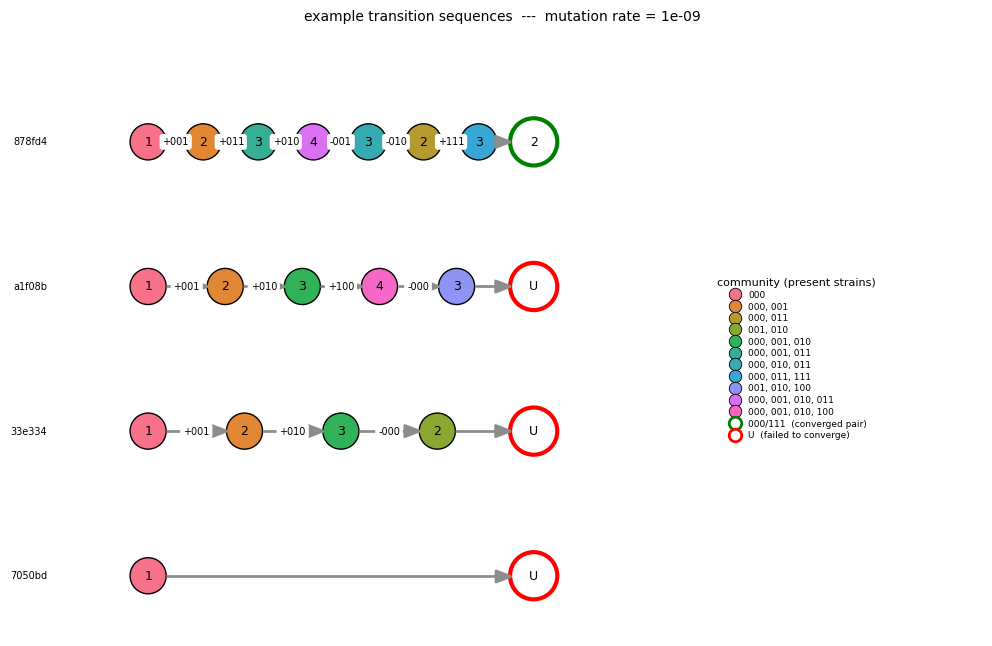

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-09+ext=.png


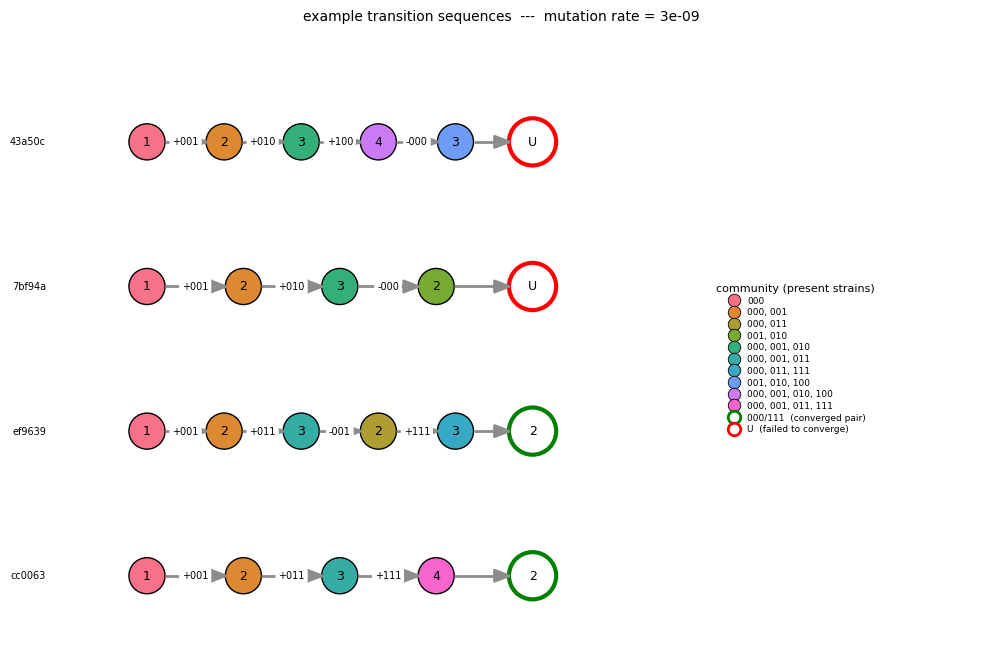

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-08+ext=.png


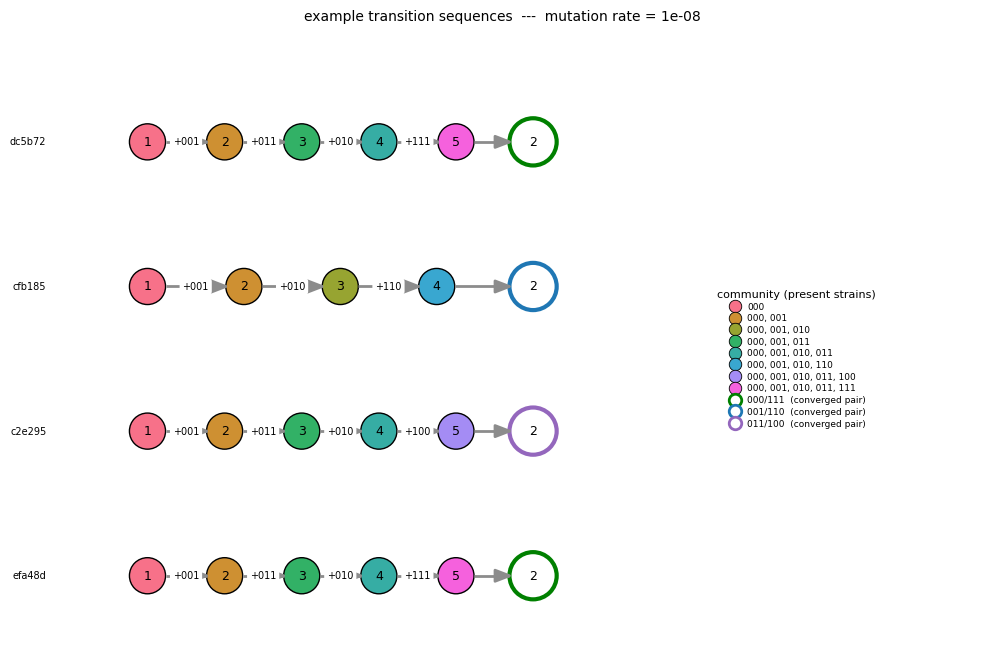

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-08+ext=.png


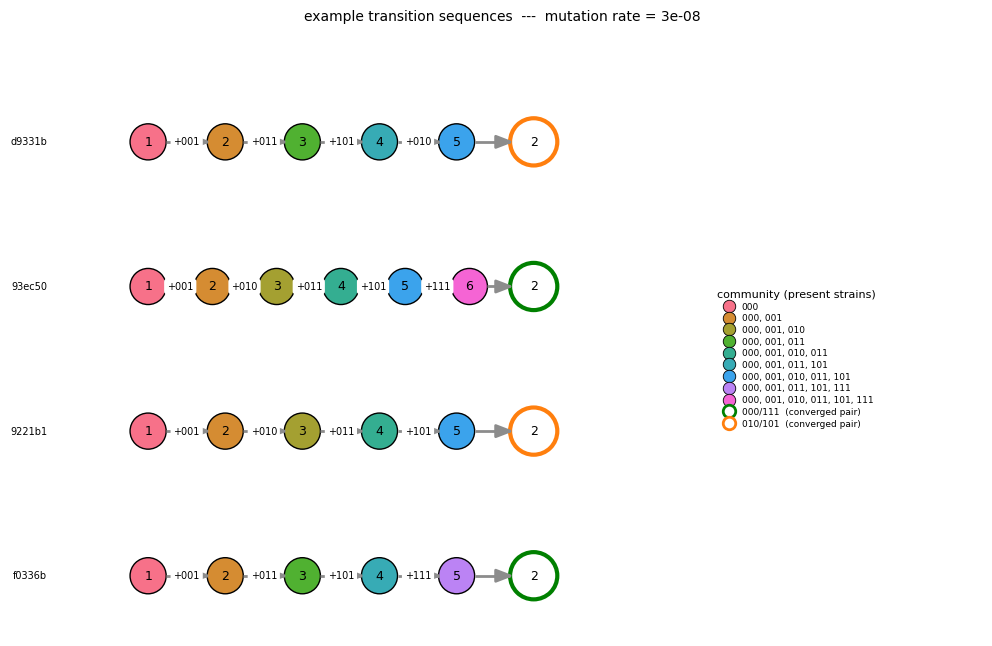

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-07+ext=.png


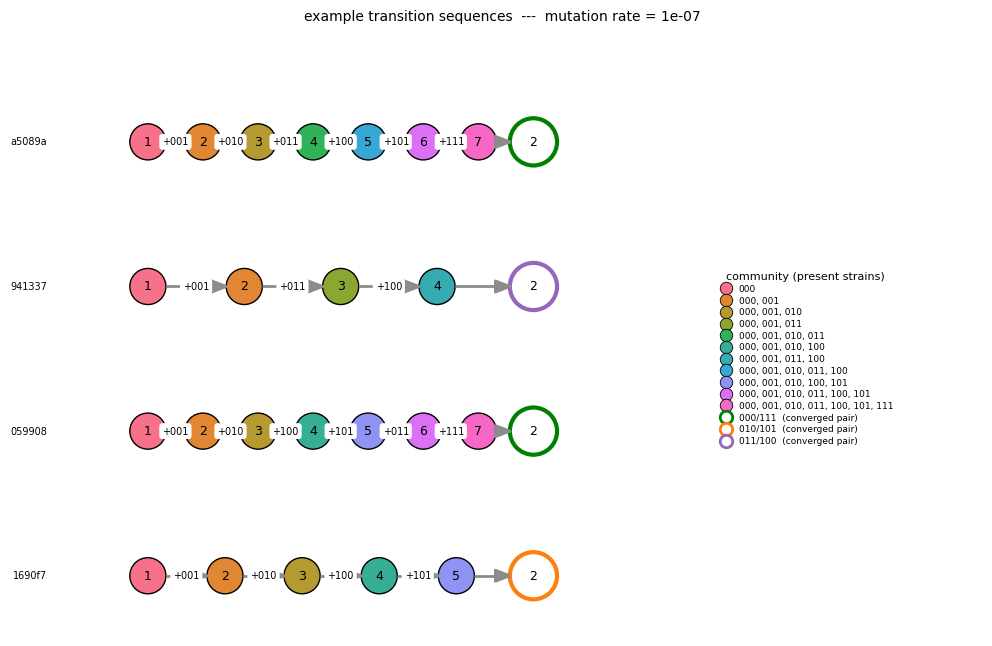

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-07+ext=.png


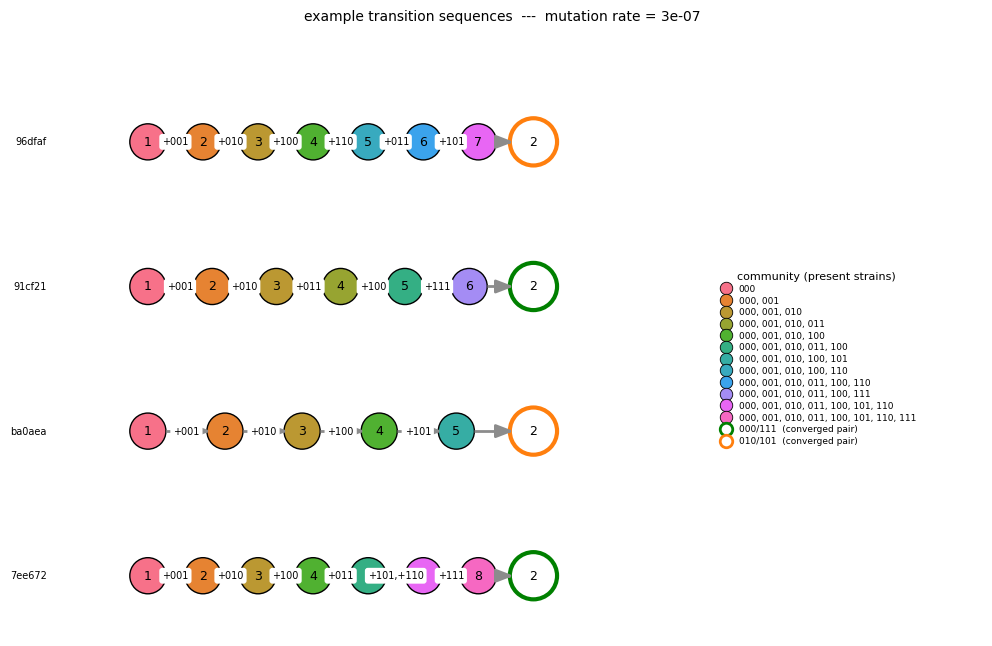

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-06+ext=.png


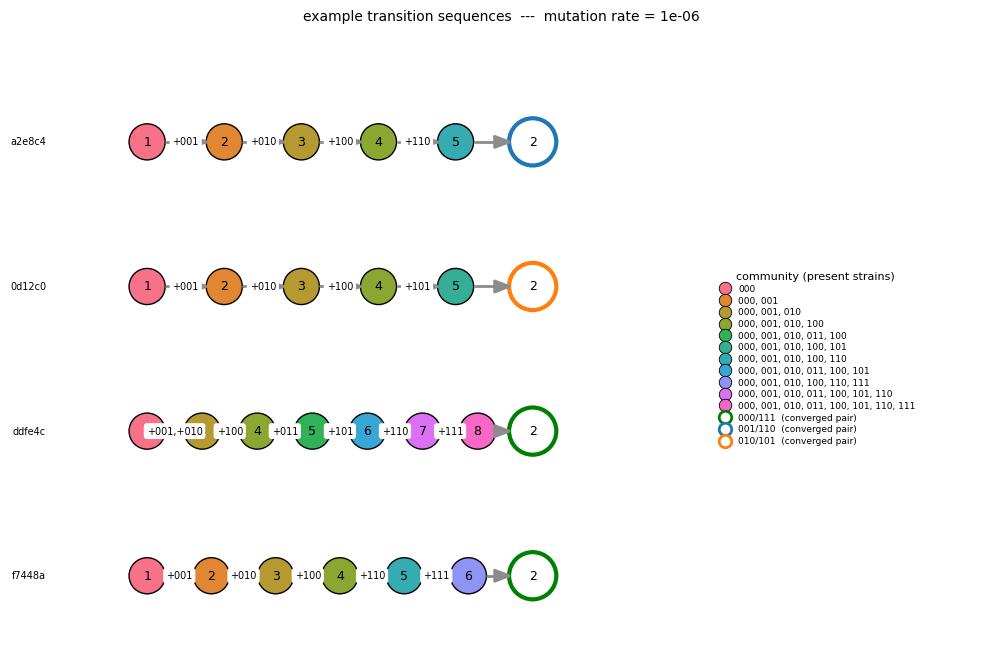

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-06+ext=.png


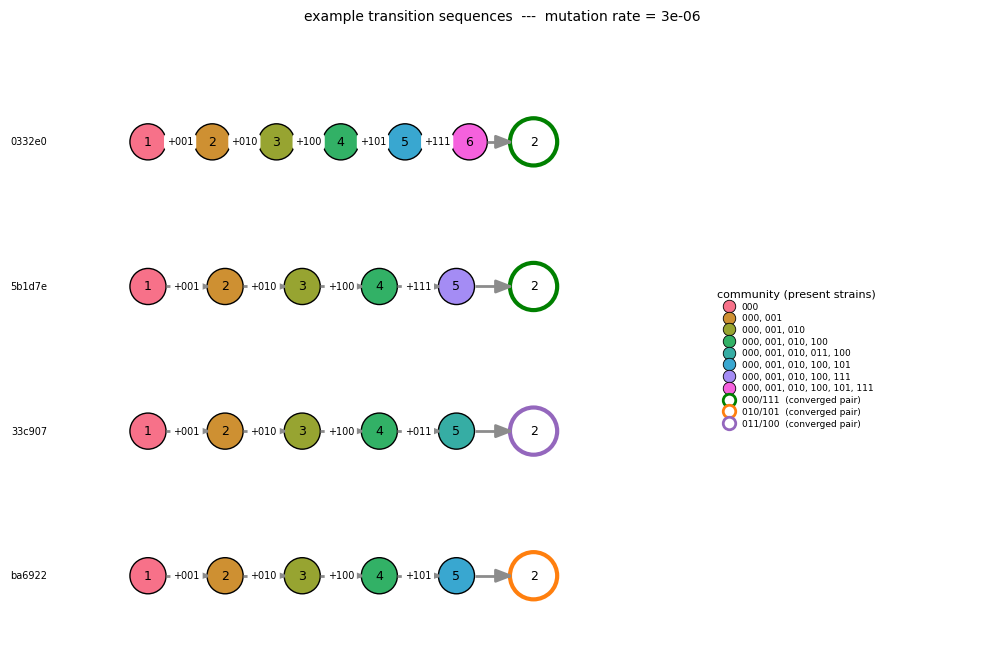

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-05+ext=.png


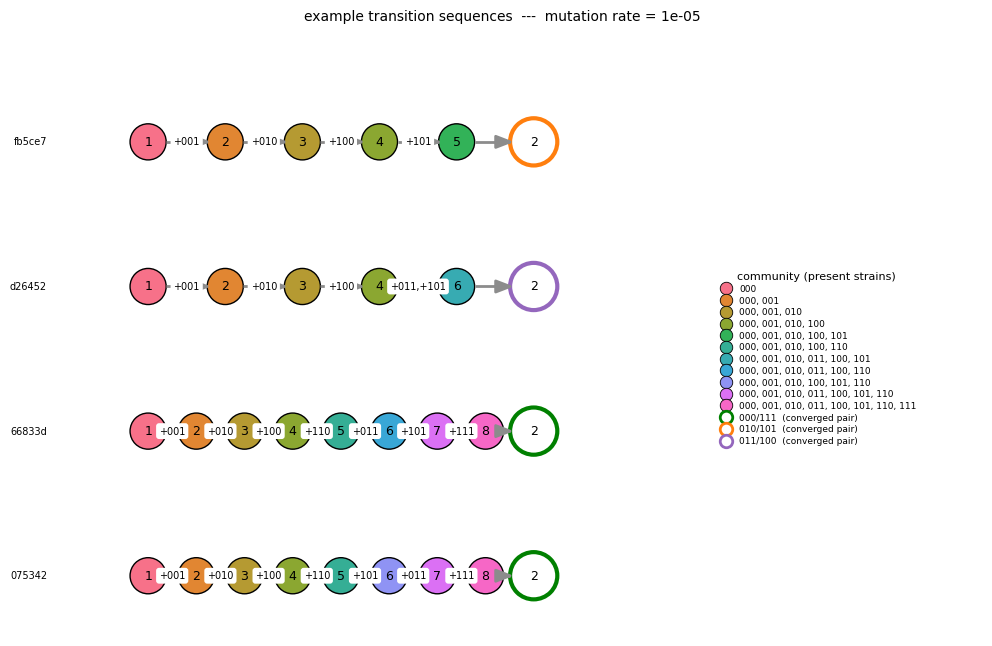

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-05+ext=.png


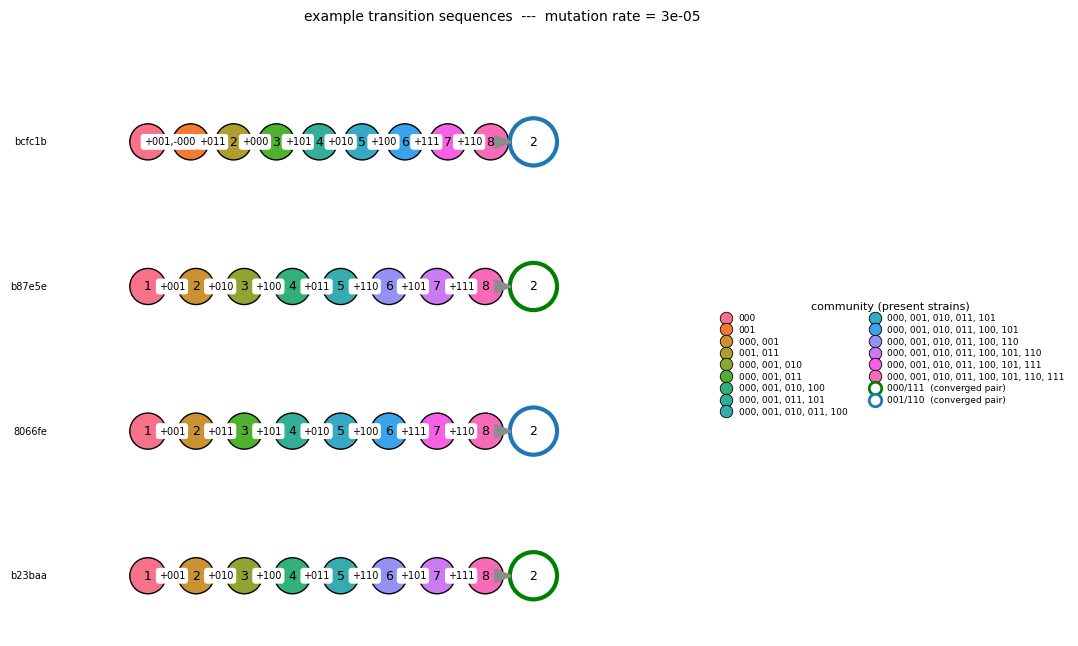

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-04+ext=.png


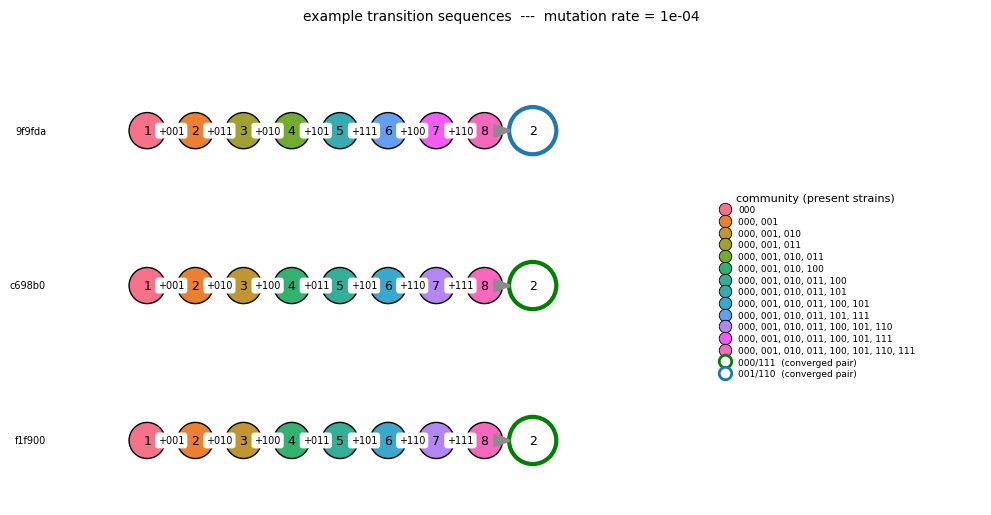

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-04+ext=.png


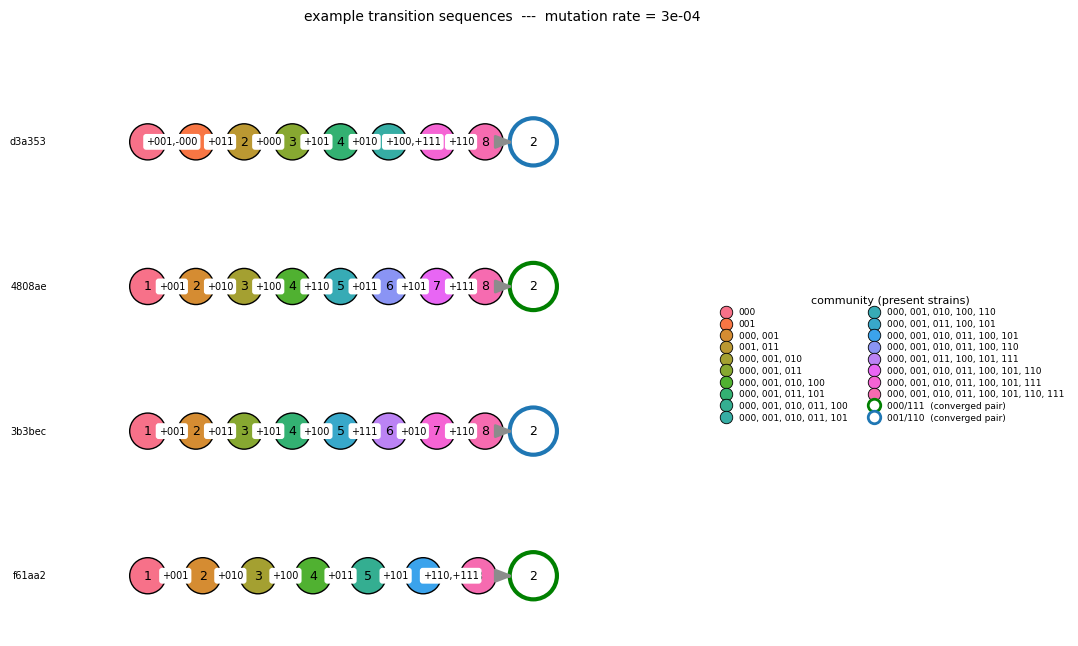

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-03+ext=.png


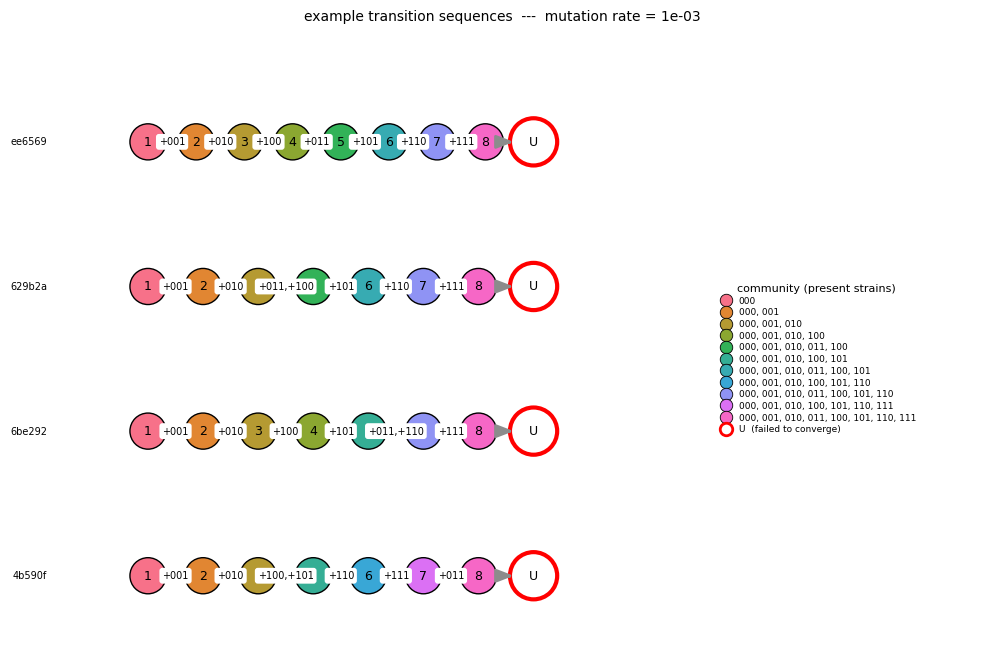

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-03+ext=.png


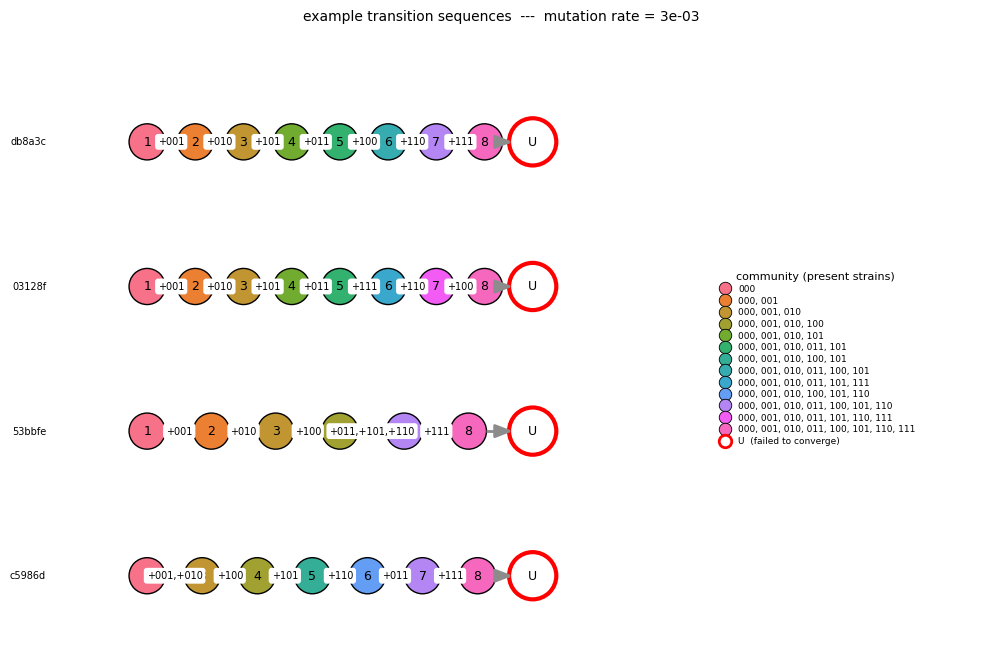

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-02+ext=.png


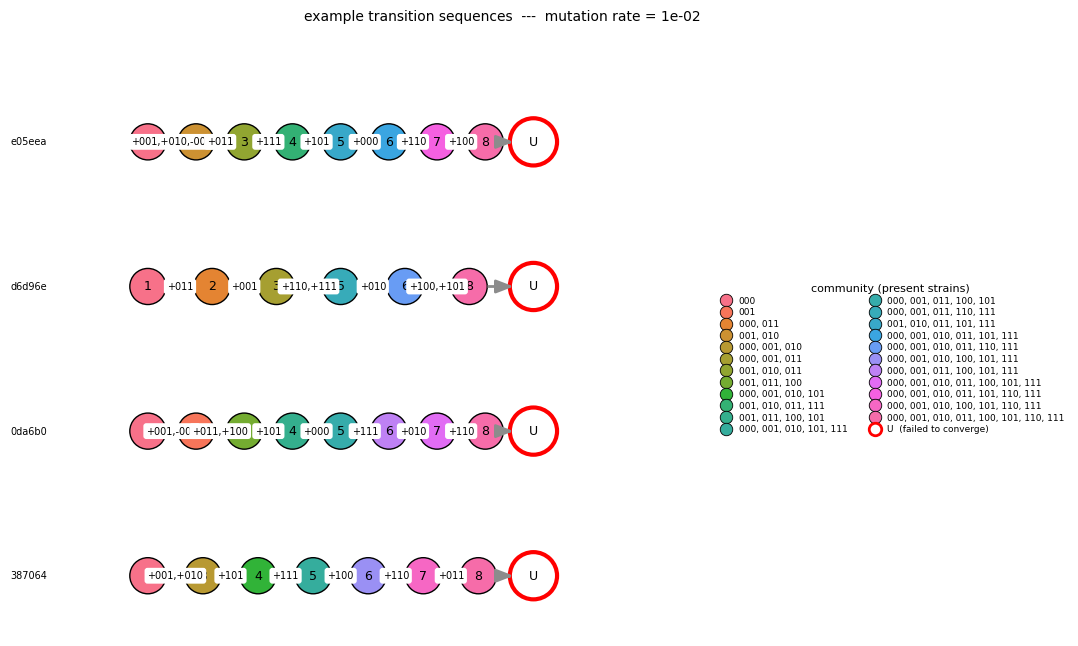

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=3e-02+ext=.png


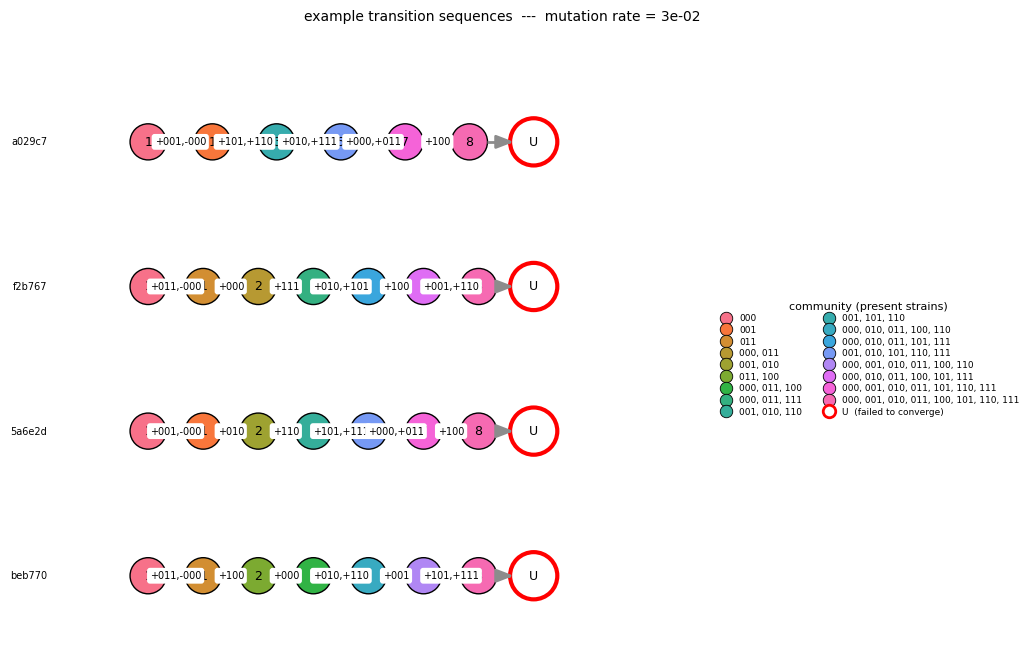

teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-01+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=example-transition-sequences+mutation-rate=1e-01+ext=.png


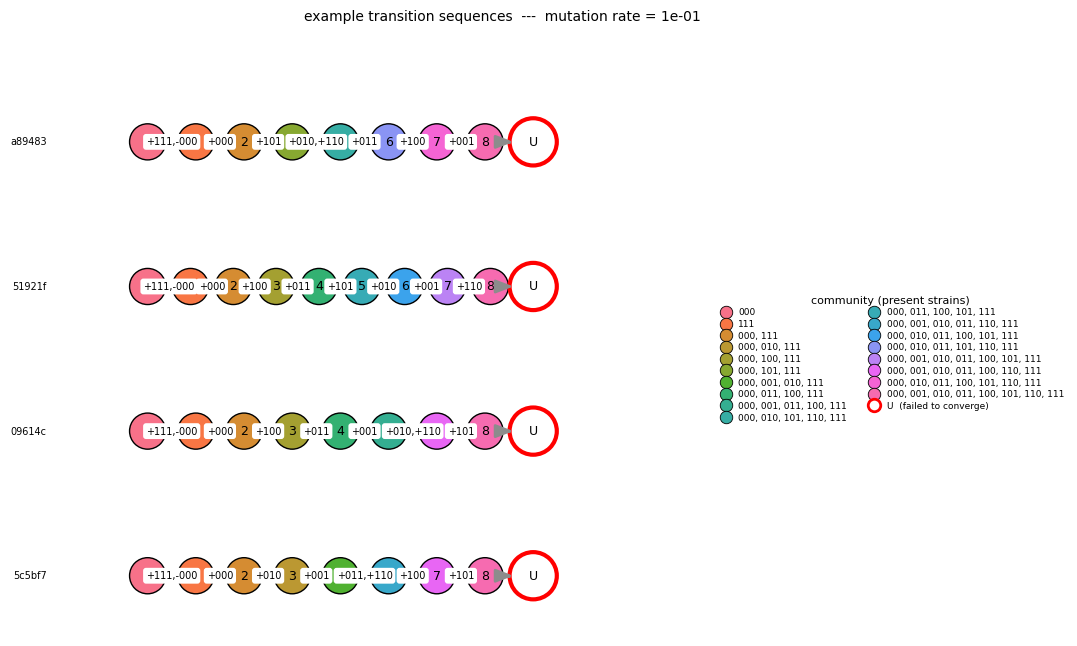

In [ ]:
for _mu in sorted(ex_df["mutation_rate"].unique()):
    _uids = (
        ex_df.loc[ex_df["mutation_rate"] == _mu, "replicate_uid"]
        .unique()
        .tolist()
    )
    plot_examples_for_mu(_mu, _uids, main_df)

## 4. Combine Graphs per Mutation Rate and Calculate Weightings

For each mutation rate we overlay every replicate's transition
sequence into one directed graph and tally:

- **node occurrences** --- transient community nodes are counted once
  per replicate they appear in; the replicate's terminal **special end
  node** (its complement pair, or `U`) is counted once. With the
  converged outcome collapsed into a complement-pair end node, every
  community node is transient and every end node is special, so the
  two classes are disjoint.
- **edge occurrences** --- how many replicate transitions follow each
  `source -> target` (including the final transition into the end
  node).

Nodes are **sized by occurrence**, with the special end nodes scaled
*among end nodes* and transient community nodes scaled *among
transient nodes* (separate scales; sizing counts occurrences, not
durations). Edges are sized by transition frequency, and each edge is
labelled with the **percentage (2 digits) of its source node's
outgoing transitions** that it accounts for. Sparse transient
nodes/edges are pruned for legibility via per-mutation-rate
minimum-occurrence thresholds; the special end nodes and the `000`
founder are always kept. Pruning is then *repaired* so every kept node
retains a directed path to some end node: any node stranded by edge
pruning has the shortest higher-traffic path back to an end node added
from the full transition graph.

In [ ]:
def aggregate(reps_df):
    """Tally node/edge occurrences across a mutation rate's replicates."""
    uids = reps_df["replicate_uid"].unique()
    end_count = defaultdict(int)
    trans_count = defaultdict(int)
    edge_count = defaultdict(int)
    out_total = defaultdict(int)
    for uid in uids:
        keys, _conv = path_with_end(
            uid, reps_df[reps_df["replicate_uid"] == uid]
        )
        seen = set()
        for i, k in enumerate(keys):
            last = i == len(keys) - 1
            role = "end" if last else "tr"
            if (k, role) not in seen:
                seen.add((k, role))
                if last:
                    end_count[k] += 1
                else:
                    trans_count[k] += 1
            if i > 0:
                edge_count[(keys[i - 1], k)] += 1
                out_total[keys[i - 1]] += 1
    return {
        "end_count": dict(end_count),
        "trans_count": dict(trans_count),
        "edge_count": dict(edge_count),
        "out_total": dict(out_total),
        "n_reps": len(uids),
    }

def build_graph(agg, min_count, min_edge):
    # Transient community nodes (frozensets) are pruned by occurrence;
    # special end nodes (complement pairs and U) are always kept, as is
    # the 000 founder.
    keep = {k for k, v in agg["trans_count"].items() if v >= min_count}
    keep |= set(agg["end_count"].keys())
    keep.add(frozenset({0}))
    occ_nodes = set(agg["trans_count"]) | set(agg["end_count"])
    keep = {k for k in keep if k in occ_nodes}
    kept_edges = {
        e: c
        for e, c in agg["edge_count"].items()
        if c >= min_edge and e[0] in keep and e[1] in keep
    }

    # Repair reachability: every kept node must retain a directed path
    # to some end node (complement pair or U). Pruning can strand a node
    # by dropping all its outgoing edges, so for any stranded node we add
    # back the shortest path to an end node from the full transition
    # graph, preferring higher-traffic edges.
    full_succ = defaultdict(list)
    for (a, b), _c in sorted(
        agg["edge_count"].items(), key=lambda kv: -kv[1]
    ):
        full_succ[a].append(b)

    def reaches_end():
        radj = defaultdict(list)
        for a, b in kept_edges:
            radj[b].append(a)
        seen = {k for k in keep if is_end_key(k)}
        stack = list(seen)
        while stack:
            x = stack.pop()
            for p in radj[x]:
                if p in keep and p not in seen:
                    seen.add(p)
                    stack.append(p)
        return seen

    reach = reaches_end()
    for n in list(keep):
        if is_end_key(n) or n in reach:
            continue
        prev = {n: None}
        queue = [n]
        qi = 0
        hit = None
        while qi < len(queue):
            x = queue[qi]
            qi += 1
            if x != n and (is_end_key(x) or x in reach):
                hit = x
                break
            for b in full_succ.get(x, []):
                if b not in prev:
                    prev[b] = x
                    queue.append(b)
        if hit is None:
            continue
        cur = hit
        while prev[cur] is not None:
            p = prev[cur]
            kept_edges[(p, cur)] = agg["edge_count"][(p, cur)]
            keep.add(p)
            keep.add(cur)
            cur = p
        reach = reaches_end()

    # Drop end nodes left with no incoming edge (an outcome whose only
    # transitions were pruned); end nodes never have outgoing edges, so
    # this strands nothing.
    indeg = {b for (_a, b) in kept_edges}
    keep = {k for k in keep if (not is_end_key(k)) or k in indeg}

    return keep, kept_edges

In [ ]:
mutation_rates = sorted(main_df["mutation_rate"].unique())
aggregates = {}
for _mu in mutation_rates:
    _sub = main_df[main_df["mutation_rate"] == _mu]
    _agg = aggregate(_sub)
    _min_count = max(2, int(0.05 * _agg["n_reps"]))
    _min_edge = max(2, int(0.03 * _agg["n_reps"]))
    _keep, _edges = build_graph(_agg, _min_count, _min_edge)
    aggregates[_mu] = {
        "agg": _agg,
        "keep": _keep,
        "edges": _edges,
        "min_count": _min_count,
        "min_edge": _min_edge,
    }
    print(
        f"mu={_mu:.0e}: n_reps={_agg['n_reps']} "
        f"kept_nodes={len(_keep)} kept_edges={len(_edges)} "
        f"(min_count={_min_count}, min_edge={_min_edge})",
    )

mu=1e-09: n_reps=200 kept_nodes=12 kept_edges=17 (min_count=10, min_edge=6)
mu=3e-09: n_reps=199 kept_nodes=19 kept_edges=23 (min_count=9, min_edge=5)
mu=1e-08: n_reps=194 kept_nodes=20 kept_edges=25 (min_count=9, min_edge=5)
mu=3e-08: n_reps=200 kept_nodes=17 kept_edges=22 (min_count=10, min_edge=6)
mu=1e-07: n_reps=196 kept_nodes=16 kept_edges=21 (min_count=9, min_edge=5)
mu=3e-07: n_reps=200 kept_nodes=14 kept_edges=21 (min_count=10, min_edge=6)
mu=1e-06: n_reps=200 kept_nodes=14 kept_edges=24 (min_count=10, min_edge=6)
mu=3e-06: n_reps=195 kept_nodes=14 kept_edges=20 (min_count=9, min_edge=5)
mu=1e-05: n_reps=200 kept_nodes=15 kept_edges=21 (min_count=10, min_edge=6)
mu=3e-05: n_reps=200 kept_nodes=13 kept_edges=19 (min_count=10, min_edge=6)
mu=1e-04: n_reps=200 kept_nodes=15 kept_edges=26 (min_count=10, min_edge=6)
mu=3e-04: n_reps=200 kept_nodes=17 kept_edges=29 (min_count=10, min_edge=6)
mu=1e-03: n_reps=200 kept_nodes=22 kept_edges=40 (min_count=10, min_edge=6)
mu=3e-03: n_reps

## 5. Per-Mutation-Rate Community Assembly Graphs

One directed community assembly graph per mutation rate, rendered with
`iplotx` (matplotlib backend) via `teeplot`. Community nodes are laid
out left-to-right by the **number of present strains**, so assembly
reads as a progression from the `000` founder toward larger
communities; the special **complement-pair** and `U` end nodes share
the rightmost column.

Transient community fill encodes the community via the color key; the
**number on each node is the count of present strains** (the
complement-pair end nodes hold 2). Special end-node sizes reflect
end-node occurrence; transient node sizes reflect transient occurrence
(separate scales). Edge width encodes transition frequency. The
`000/111` complement-pair end node is outlined **green** and the
non-convergence `U` end node **red**; the remaining pairs carry their
own outline colors.

Three versions of each graph are rendered and saved (tagged via
`teeplot_outattrs` `edge-labels=pct` vs `edge-labels=delta` vs
`edge-labels=none`): one with each edge labelled by the 2-digit
percentage of its source's outgoing transitions, one with each edge
between transient communities labelled by the strain introduced
(`+100`) or gone extinct (`-010`) in that transition (edges into a
special end node are left unlabelled), and one with bare arrows.

In [ ]:
def layout_layered(keep):
    """x = community size; special end nodes share the rightmost column."""
    cols = defaultdict(list)
    for k in keep:
        x = None if is_end_key(k) else len(k)
        cols[x].append(k)
    coords = {}
    sizes = sorted(x for x in cols if x is not None)
    maxx = max(sizes) if sizes else 1
    for x in sizes:
        nodes = sorted(cols[x], key=lambda k: (-len(k), tuple(sorted(k))))
        n = len(nodes)
        ys = (
            np.linspace(-(n - 1) / 2.0, (n - 1) / 2.0, n)
            if n > 1
            else [0.0]
        )
        for k, y in zip(nodes, ys):
            coords[k] = (float(x), float(y) * 1.6)
    if None in cols:
        ends = sorted(cols[None], key=lambda k: (k == "U", k))
        n = len(ends)
        ys = (
            np.linspace(-(n - 1) / 2.0, (n - 1) / 2.0, n)
            if n > 1
            else [0.0]
        )
        for k, y in zip(ends, ys):
            coords[k] = (float(maxx + 1), float(y) * 1.8)
    return coords

In [ ]:
def plot_mu(
    mu, bundle, ax, legend_ax, palette="husl", edge_label_mode="pct"
):
    agg = bundle["agg"]
    keep = bundle["keep"]
    kept_edges = bundle["edges"]
    ec = agg["end_count"]
    tc = agg["trans_count"]

    def _sort_key(k):
        if is_end_key(k):
            return (1, 99, (), k)
        return (0, len(k), tuple(sorted(k)), "")

    nodes = sorted(keep, key=_sort_key)
    idx = {k: i for i, k in enumerate(nodes)}
    coords = layout_layered(keep)

    # Special end nodes (pairs and U) vs transient community nodes are
    # disjoint classes, sized on separate scales.
    end_nodes = {k for k in nodes if is_end_key(k)}
    max_end = max([ec.get(k, 0) for k in end_nodes] + [1])
    max_tr = max([tc.get(k, 0) for k in nodes if k not in end_nodes] + [1])

    g = ig.Graph(directed=True)
    g.add_vertices(len(nodes))
    elist, ewidth, elabel_pct, elabel_delta = [], [], [], []
    max_e = max(kept_edges.values()) if kept_edges else 1
    for (a, b), c in kept_edges.items():
        elist.append((idx[a], idx[b]))
        ewidth.append(1.0 + 4.0 * (c / max_e))
        pct = 100.0 * c / max(agg["out_total"].get(a, c), 1)
        elabel_pct.append(f"{min(pct, 99):02.0f}%")
        elabel_delta.append(edge_delta_label(a, b))
    g.add_edges(elist)
    elabel = {"pct": elabel_pct, "delta": elabel_delta, "none": None}[
        edge_label_mode
    ]

    colors = sns.color_palette(
        palette,
        n_colors=max(3, len([k for k in nodes if not is_end_key(k)])),
    )
    vsize, vface, vedge, vlw, vlabel = [], [], [], [], []
    colormap = {}
    ci = 0
    for k in nodes:
        if is_end_key(k):
            vsize.append(16.0 + 34.0 * np.sqrt(ec.get(k, 0) / max_end))
            vface.append("white")
            vedge.append(END_OUTLINE.get(k, "black"))
            vlw.append(3.0)
        else:
            colormap[k] = colors[ci]
            ci += 1
            vsize.append(7.0 + 20.0 * np.sqrt(tc.get(k, 0) / max_tr))
            vface.append(colormap[k])
            vedge.append("black")
            vlw.append(1.0)
        vlabel.append(node_count_label(k))

    iplotx.network(
        g,
        layout=[coords[k] for k in nodes],
        vertex_labels=vlabel,
        edge_labels=elabel,
        ax=ax,
        vertex_facecolor=vface,
        vertex_edgecolor=vedge,
        vertex_size=vsize,
        vertex_linewidth=vlw,
        edge_linewidth=ewidth,
        edge_color="0.55",
        vertex_label_color="black",
        vertex_label_size=8,
        edge_label_size=7,
        edge_label_rotate=False,
        show=False,
    )
    ax.set_title(
        f"mutation rate = {mu:.0e}   (n={agg['n_reps']} replicates)"
    )
    ax.margins(0.08)

    # ---- color-coded key ----
    legend_ax.axis("off")
    handles, labels = [], []
    for k in nodes:
        if is_end_key(k):
            handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    markerfacecolor="white",
                    markeredgecolor=END_OUTLINE.get(k, "black"),
                    markeredgewidth=2.0,
                    markersize=9,
                )
            )
            labels.append(node_text(k))
            continue
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=colormap[k],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=9,
            )
        )
        labels.append(node_text(k))
    legend_ax.legend(
        handles,
        labels,
        loc="center left",
        fontsize=6.5,
        title="community (present strains)",
        title_fontsize=8,
        ncol=1 if len(nodes) <= 18 else 2,
        frameon=False,
        handletextpad=0.4,
        labelspacing=0.3,
        borderaxespad=0.0,
    )

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-09+ext=.png


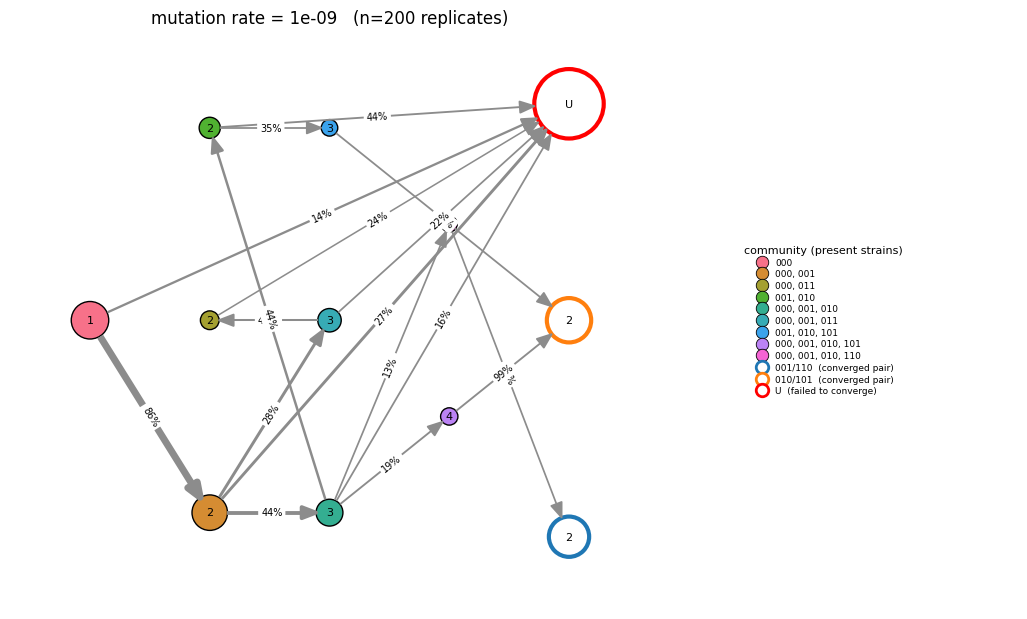

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-09+ext=.png


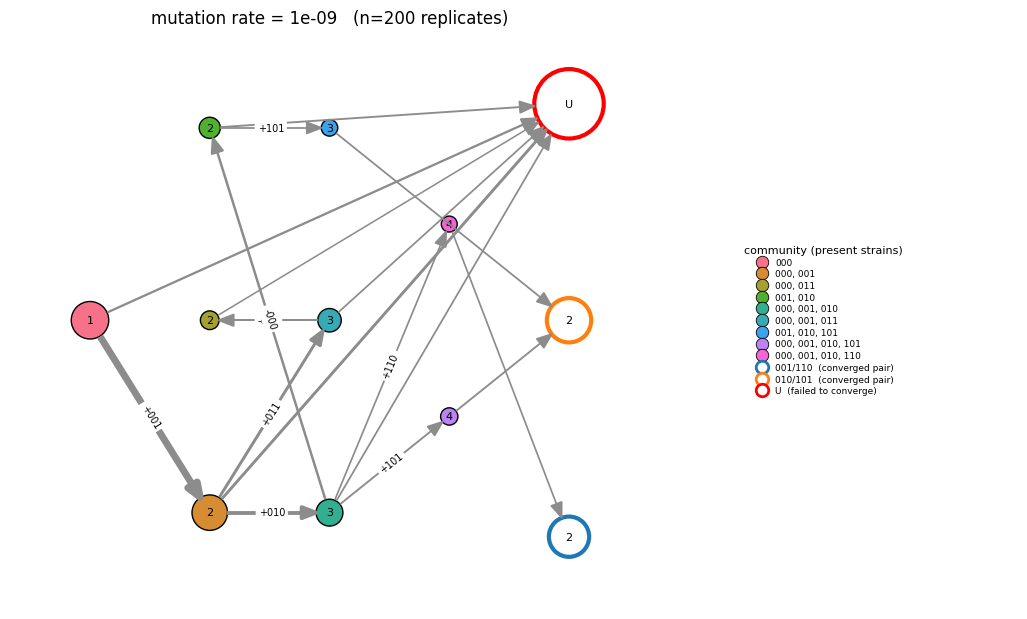

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-09+ext=.png


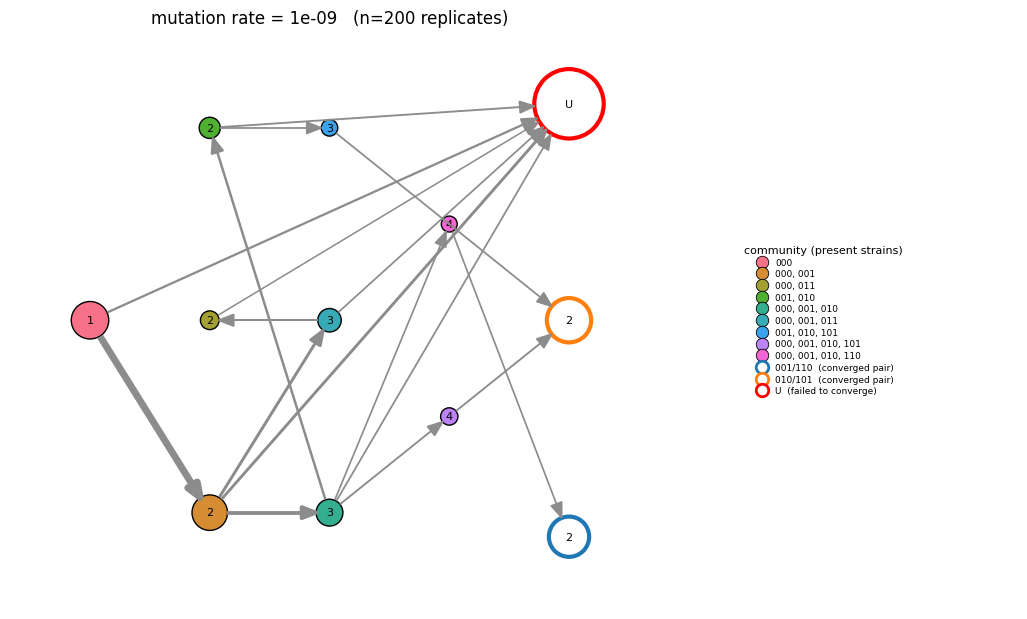

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-09+ext=.png


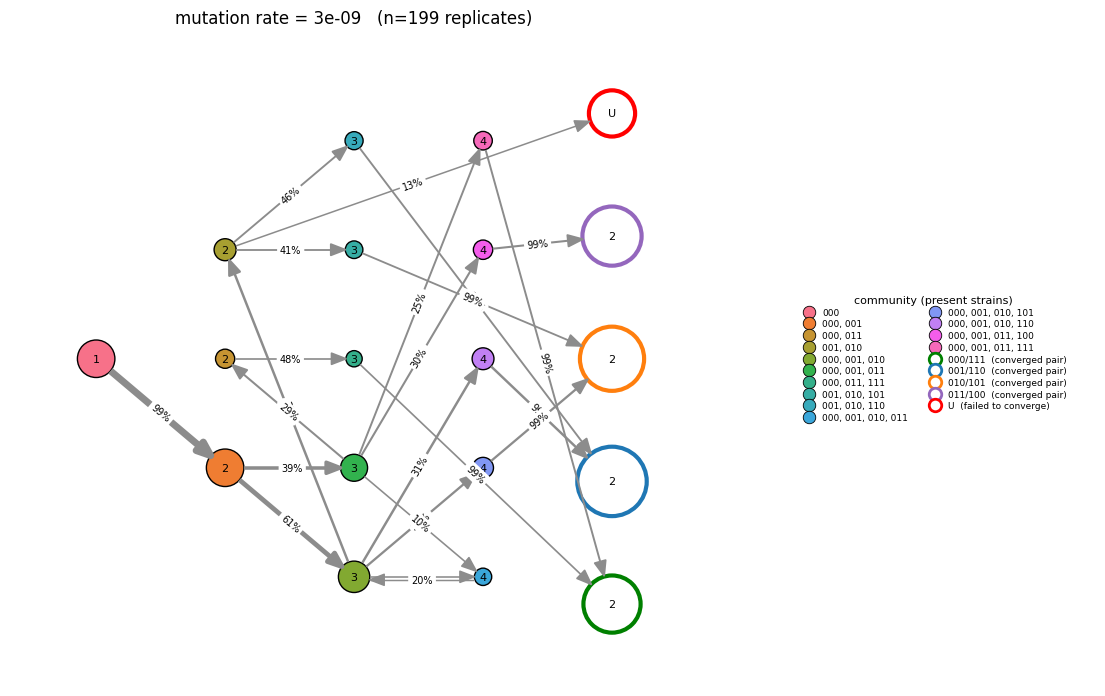

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-09+ext=.png


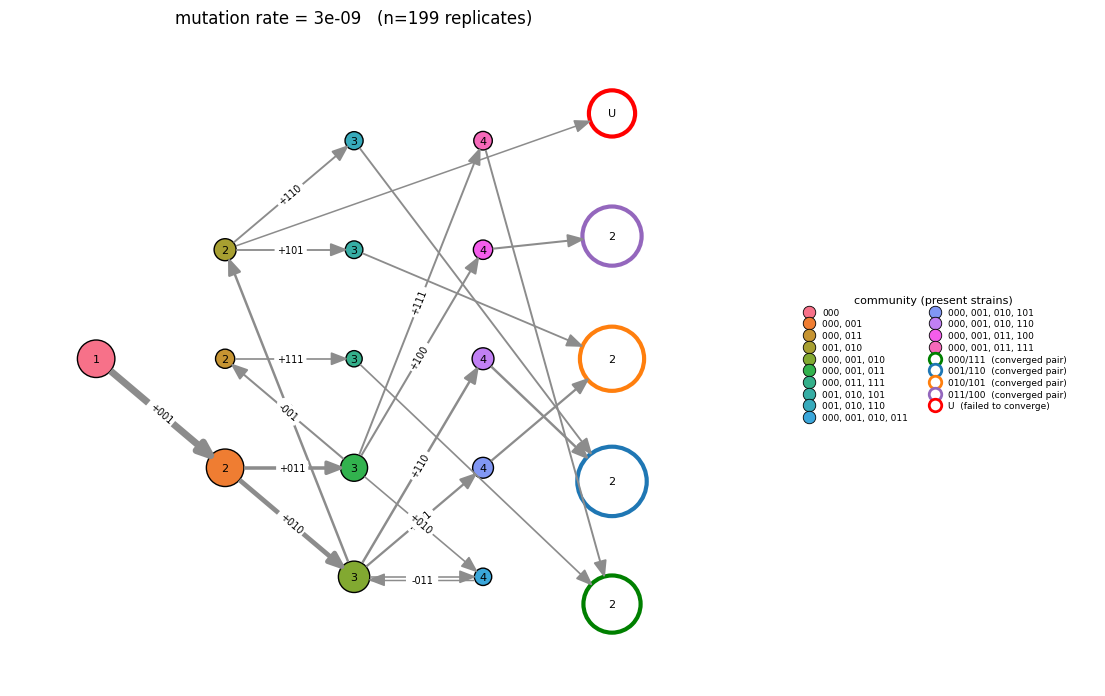

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-09+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-09+ext=.png


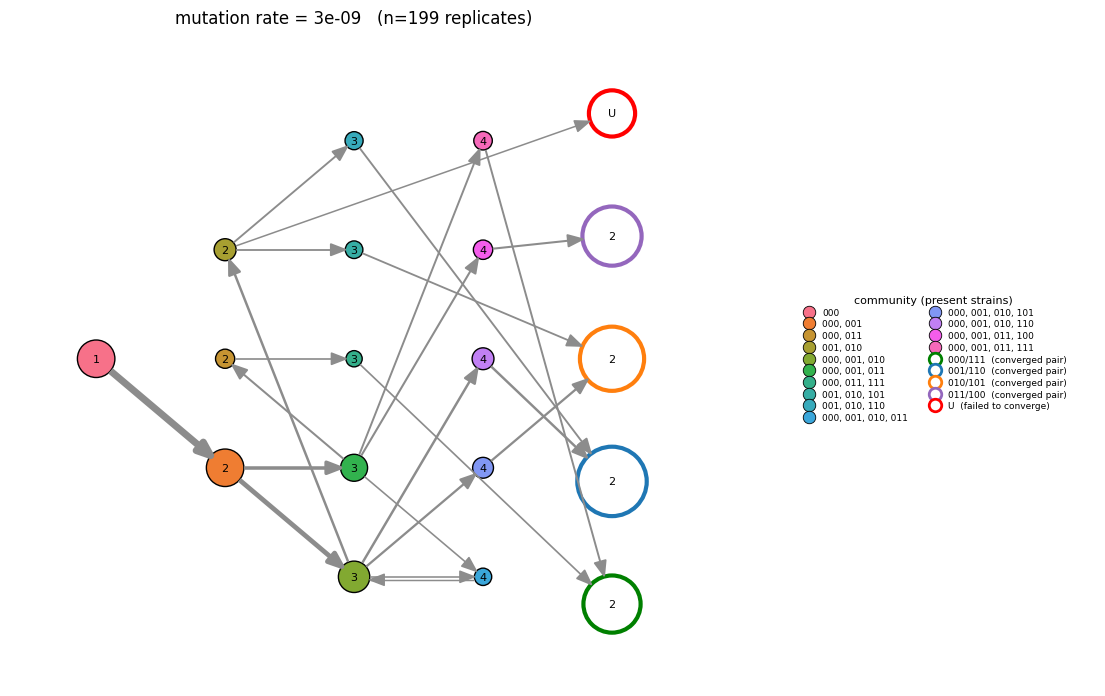

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-08+ext=.png


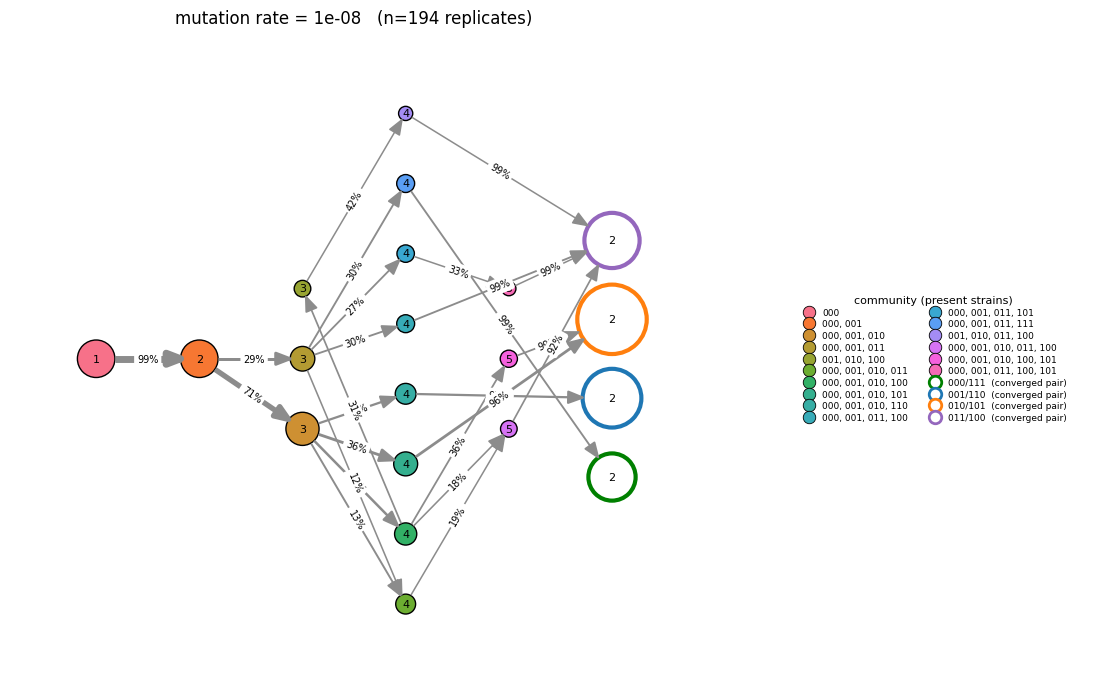

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-08+ext=.png


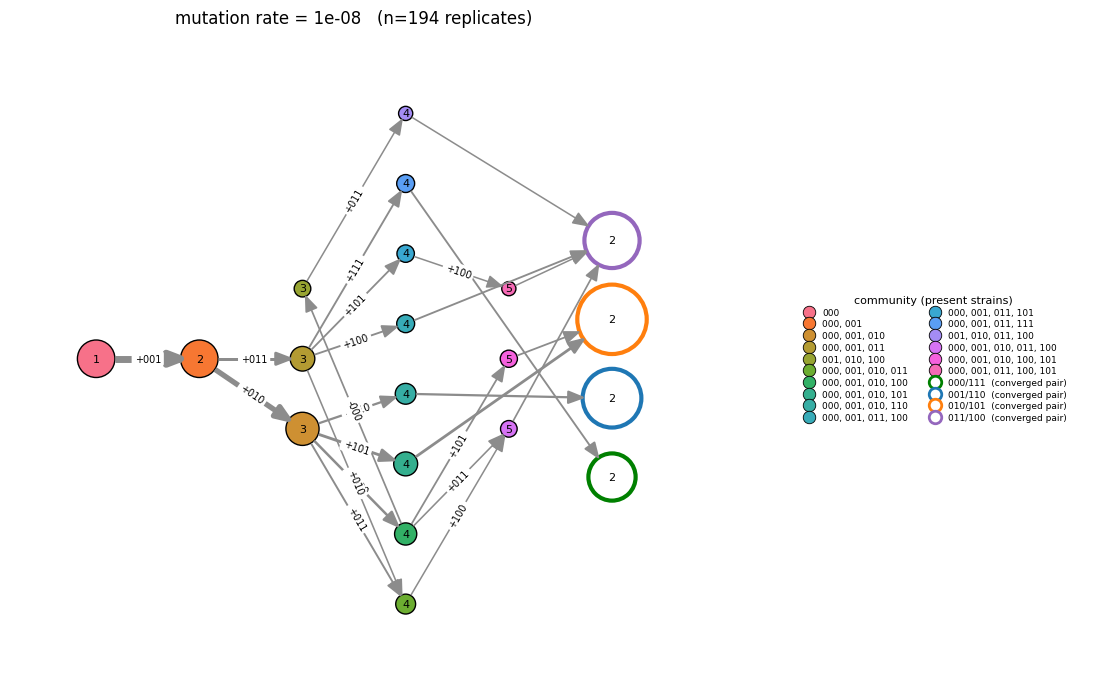

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-08+ext=.png


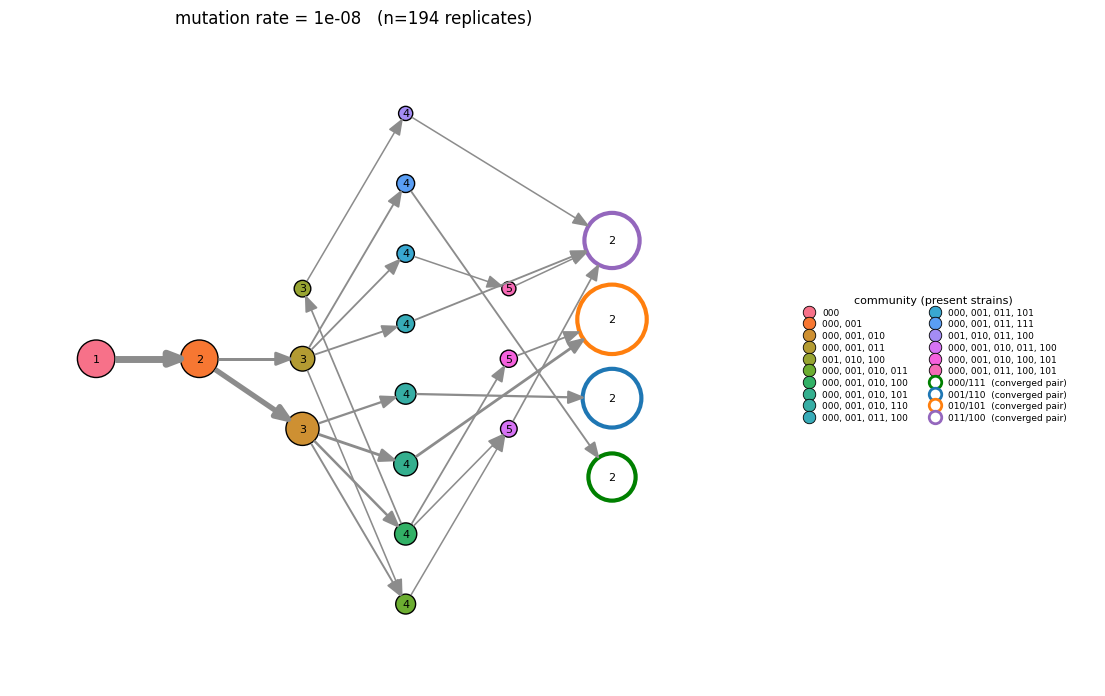

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-08+ext=.png


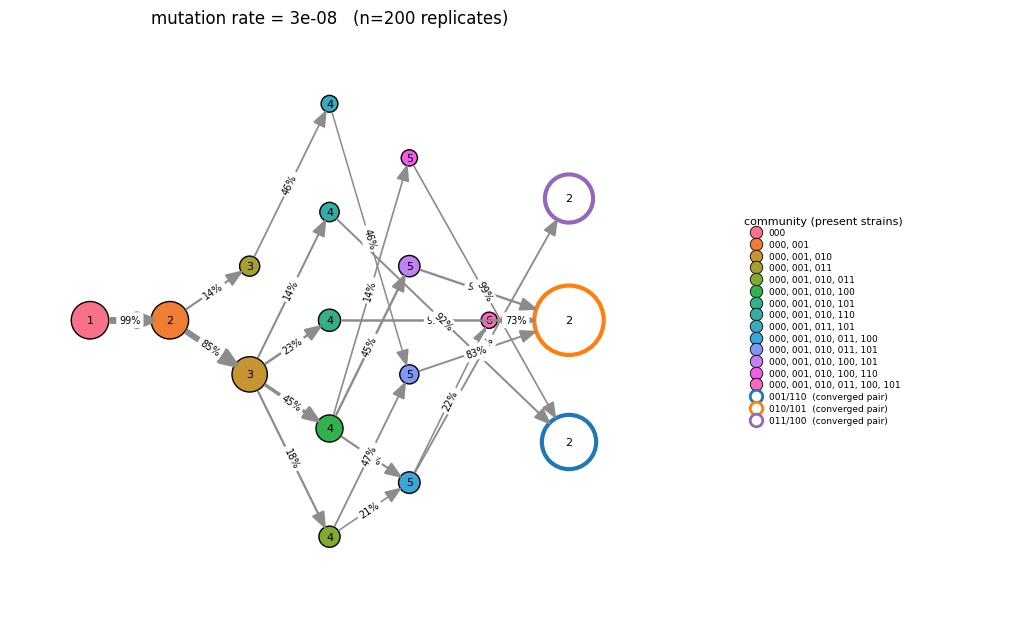

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-08+ext=.png


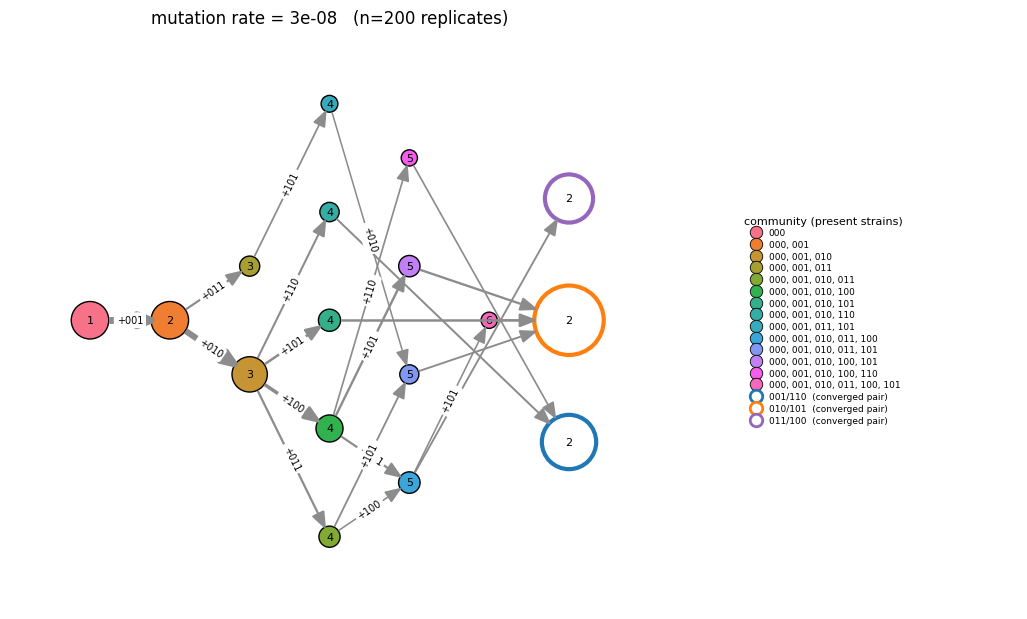

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-08+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-08+ext=.png


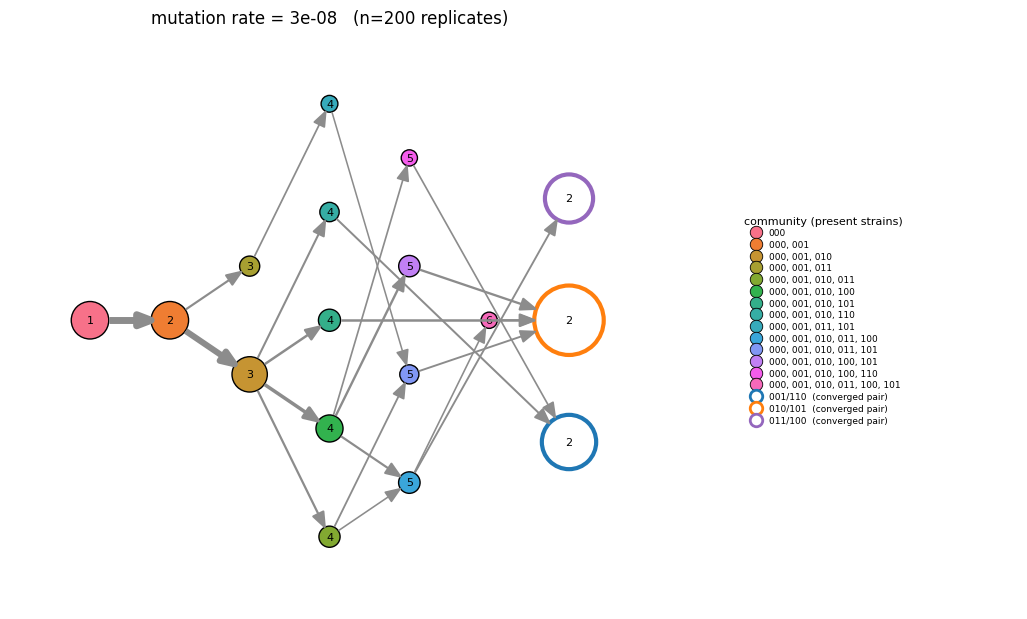

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-07+ext=.png


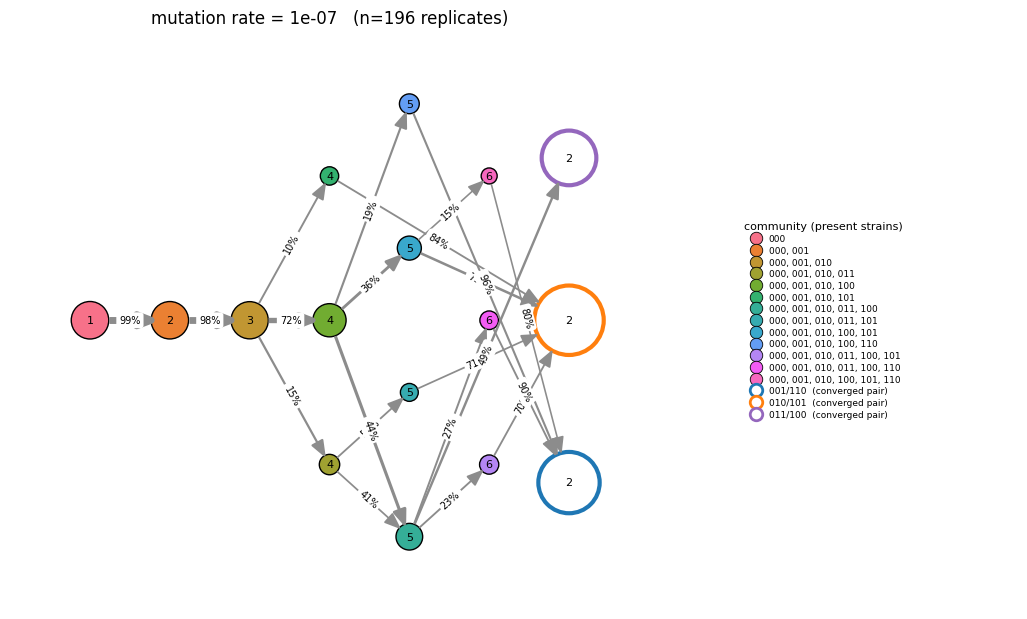

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-07+ext=.png


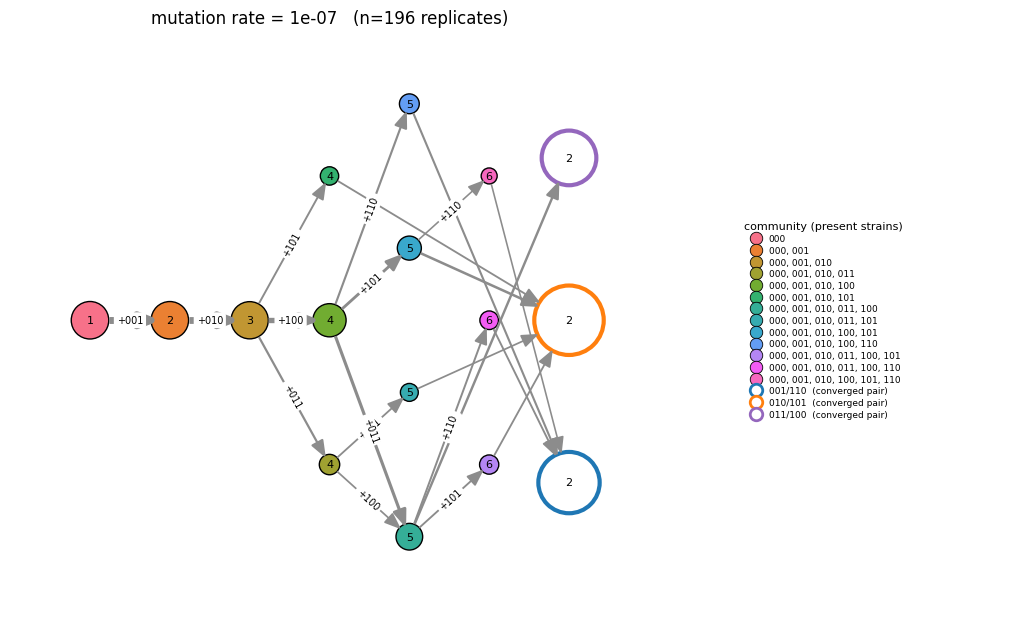

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-07+ext=.png


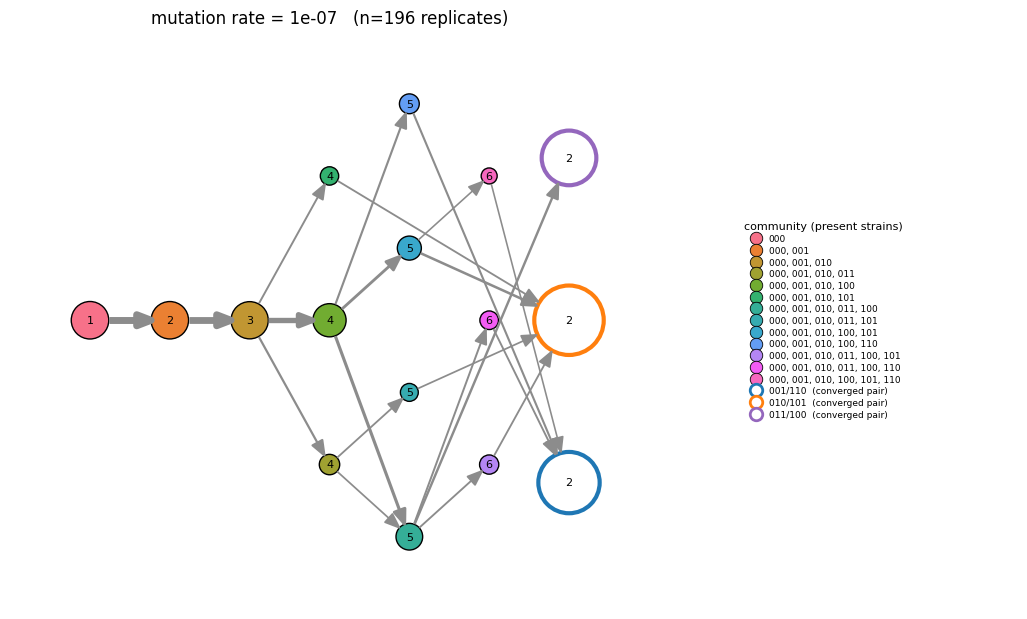

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-07+ext=.png


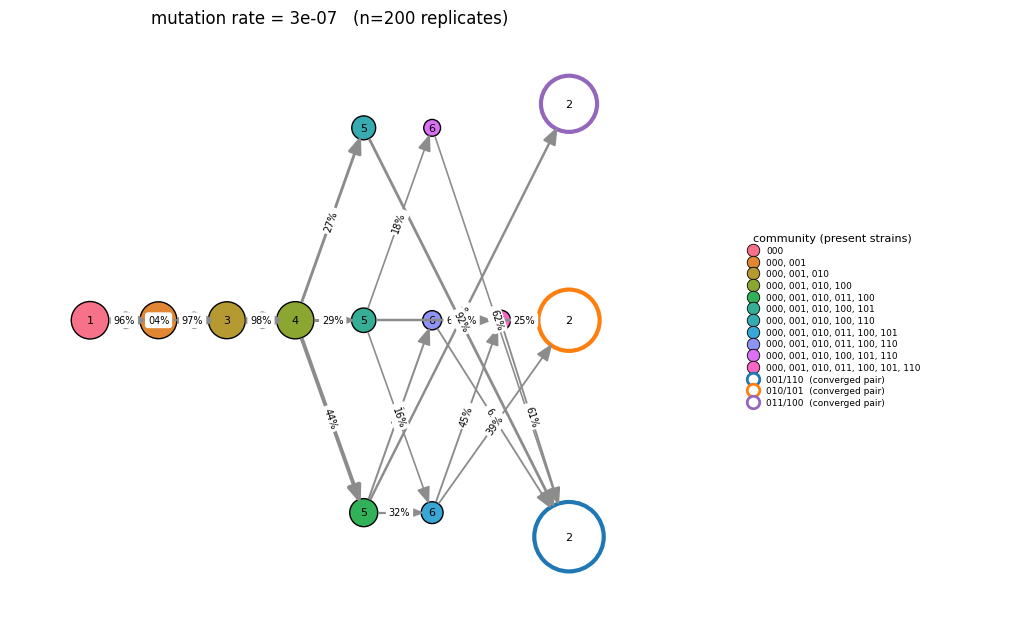

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-07+ext=.png


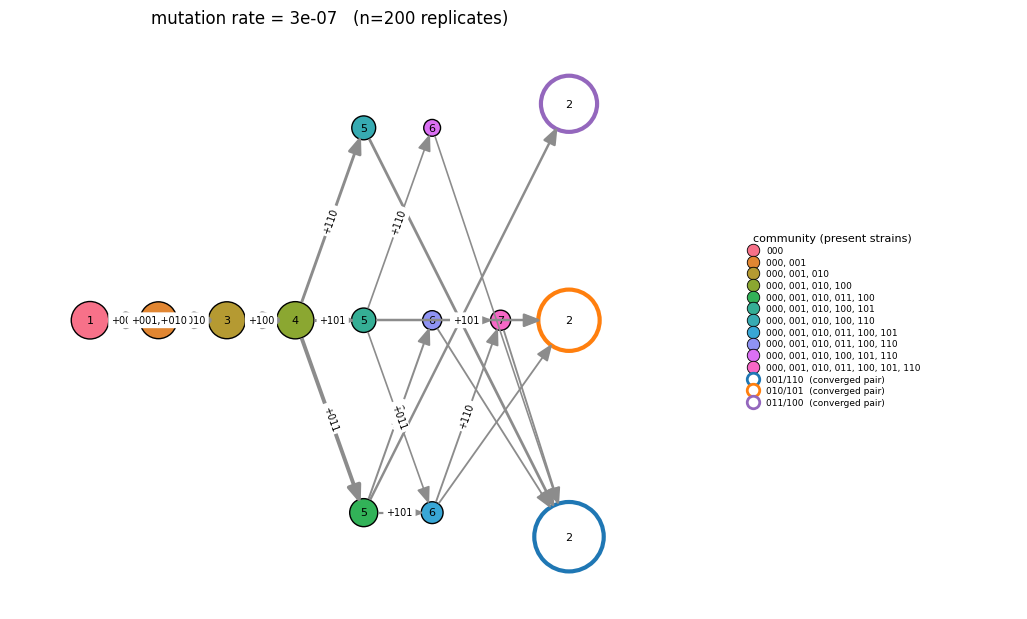

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-07+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-07+ext=.png


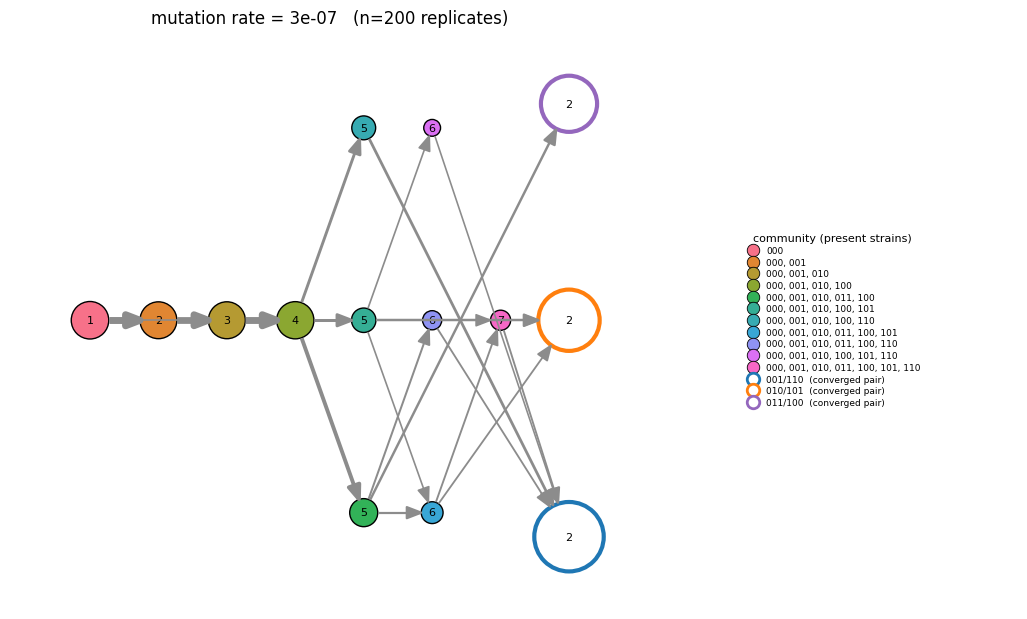

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-06+ext=.png


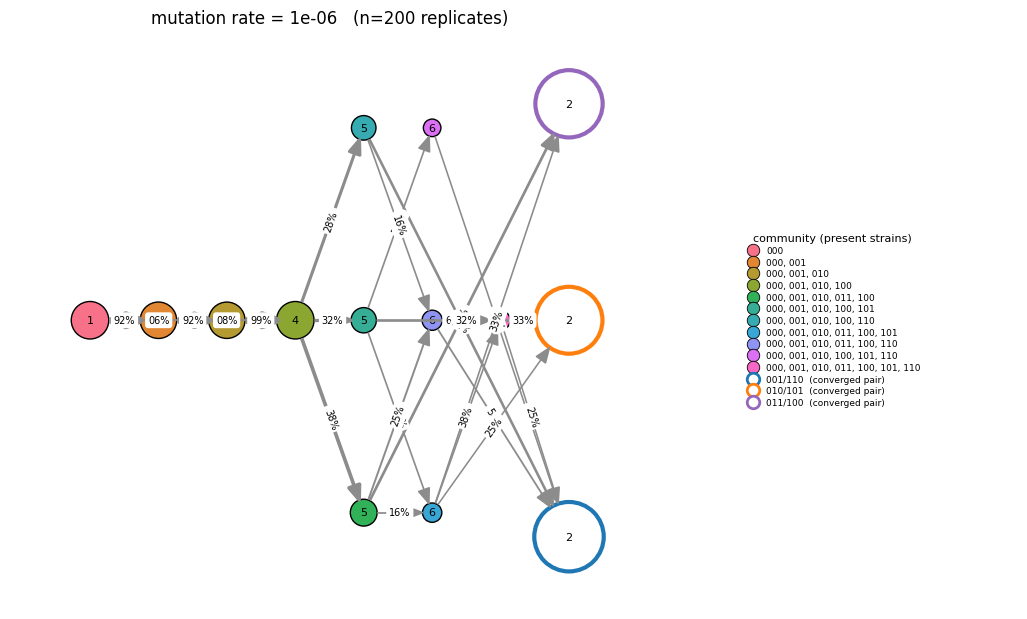

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-06+ext=.png


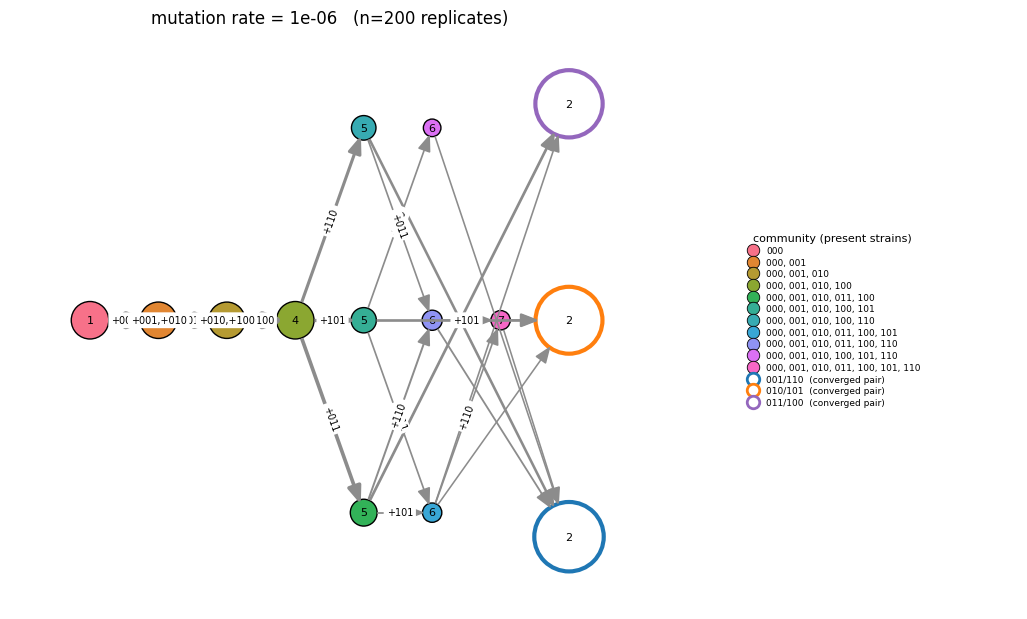

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-06+ext=.png


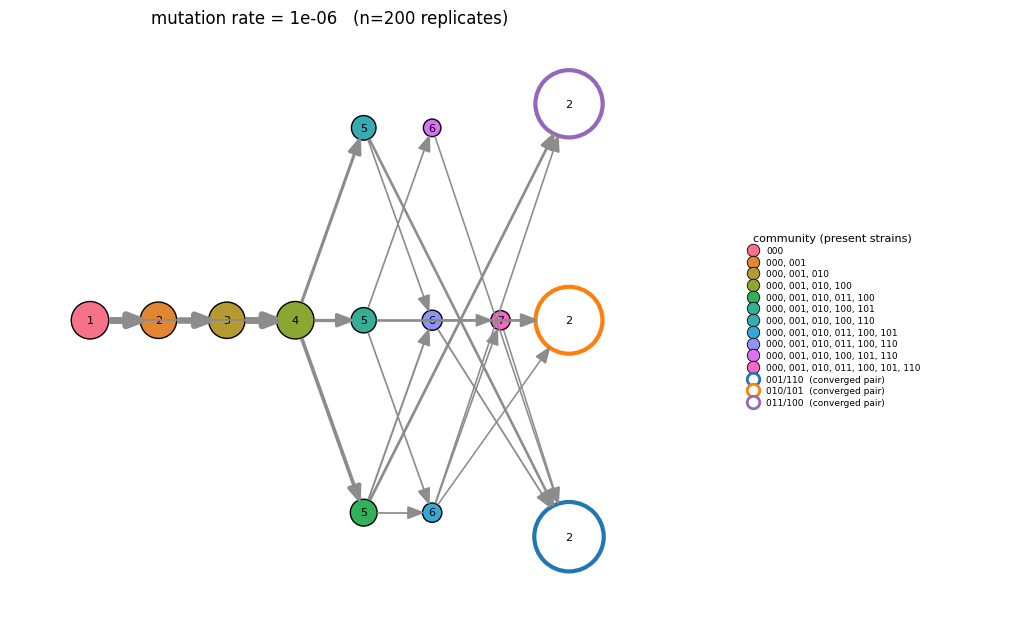

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-06+ext=.png


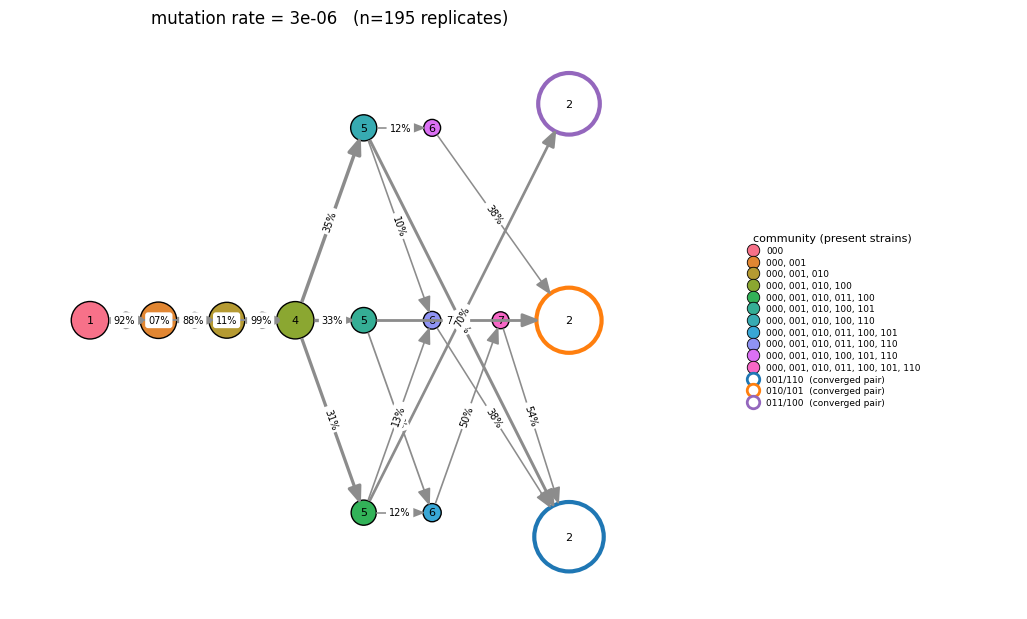

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-06+ext=.png


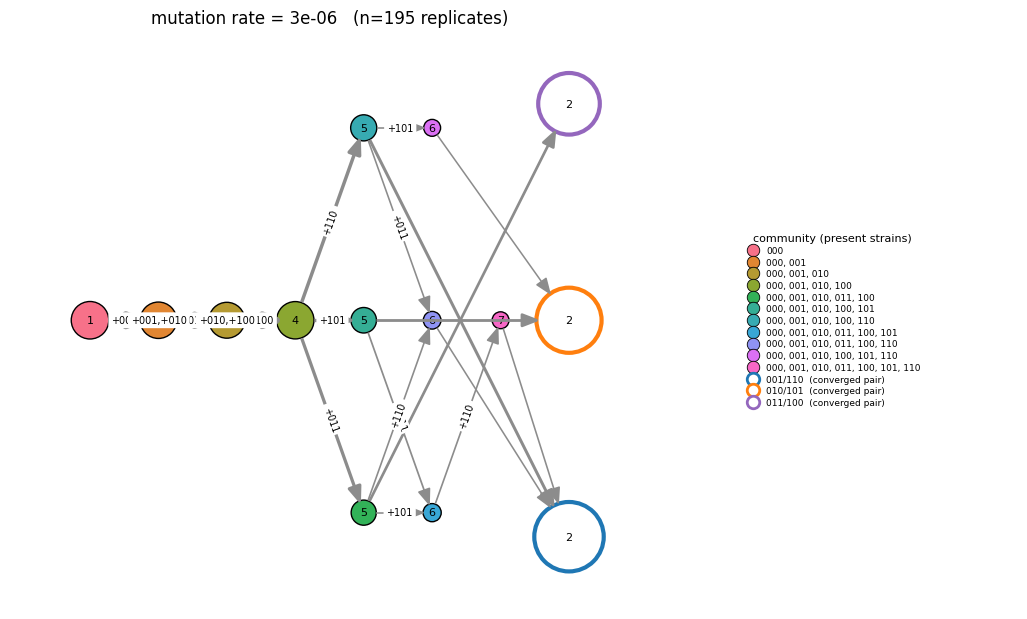

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-06+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-06+ext=.png


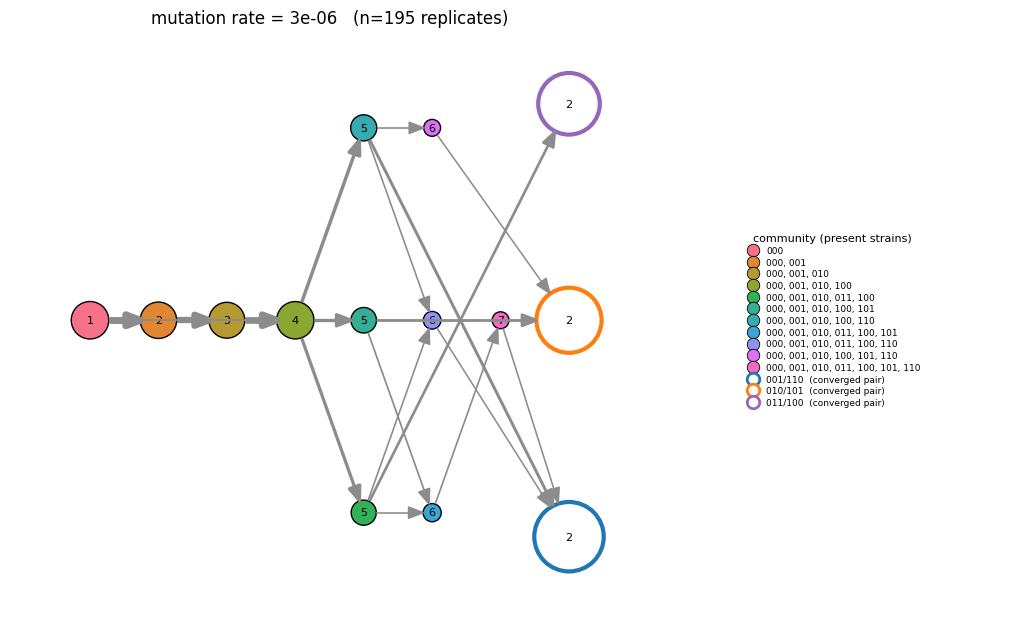

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-05+ext=.png


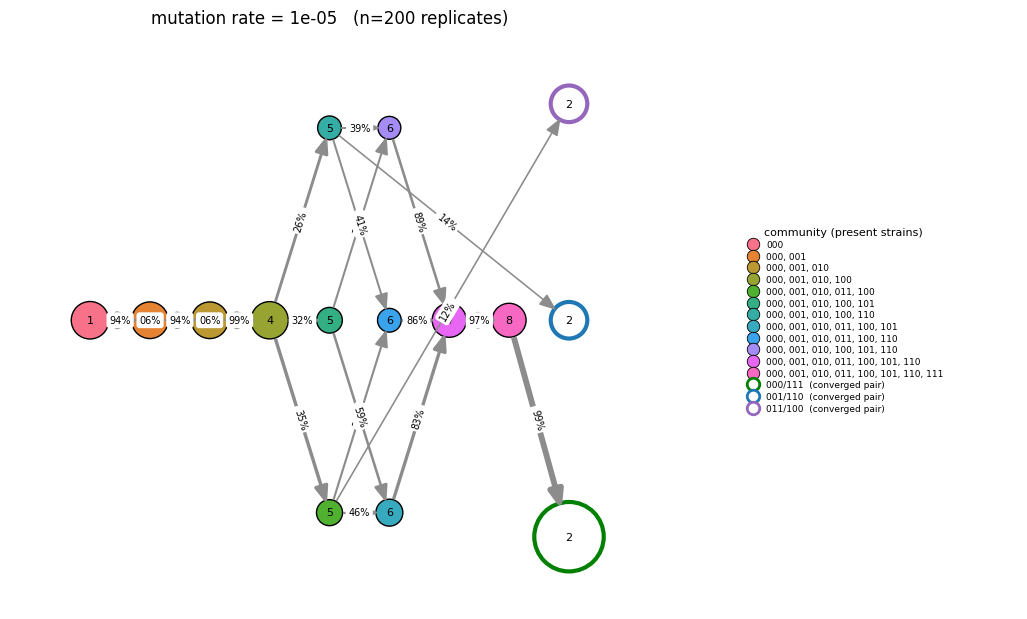

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-05+ext=.png


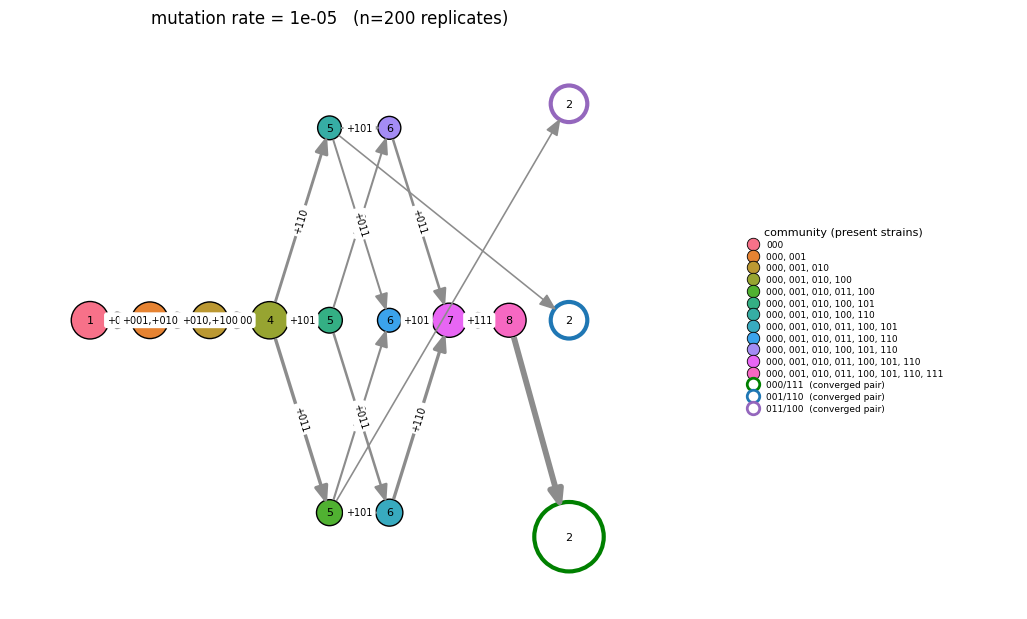

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-05+ext=.png


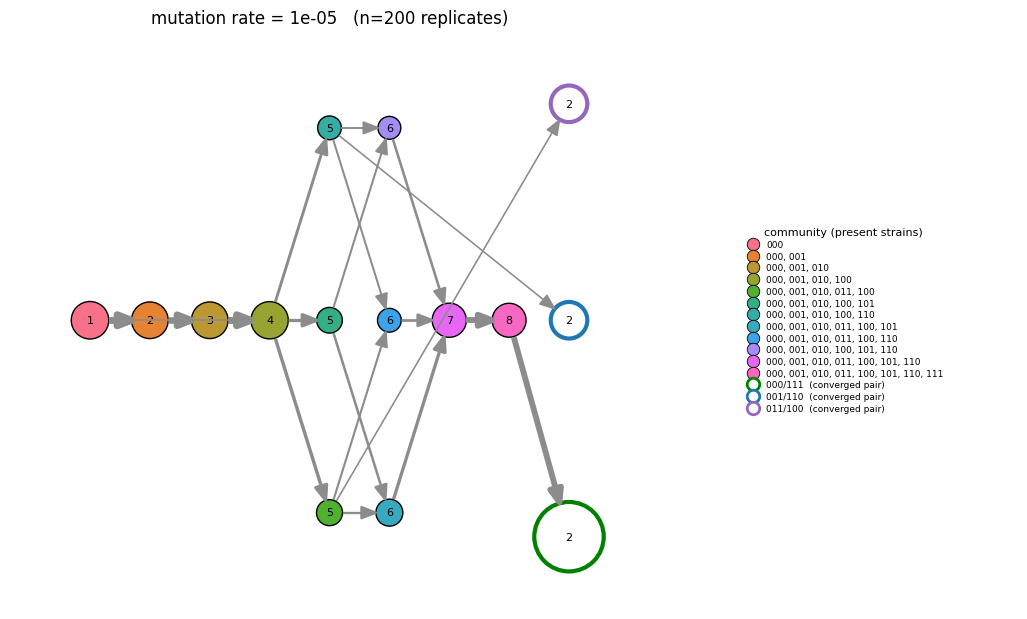

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-05+ext=.png


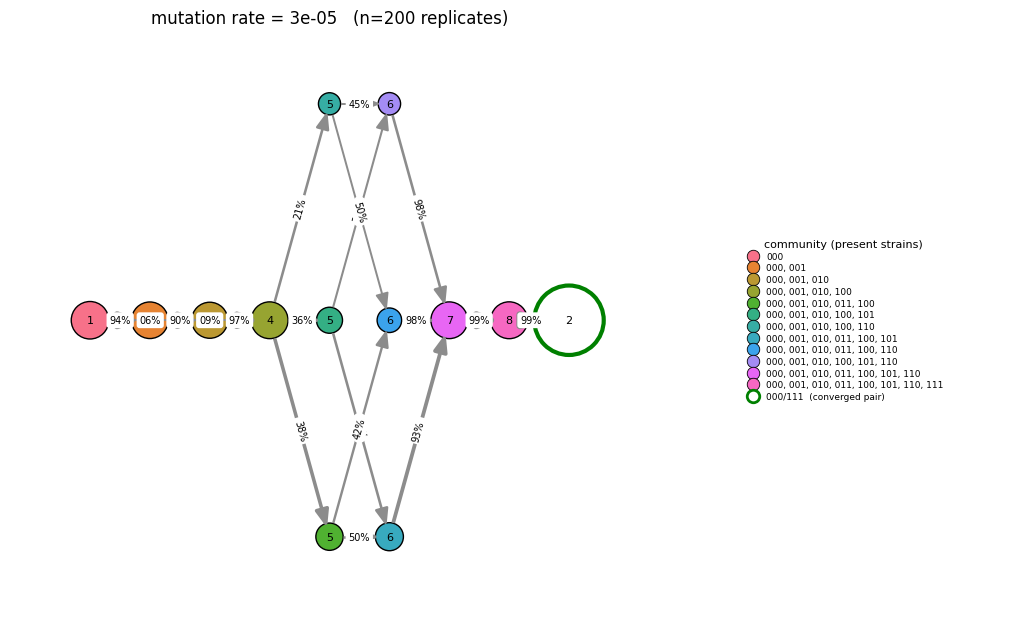

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-05+ext=.png


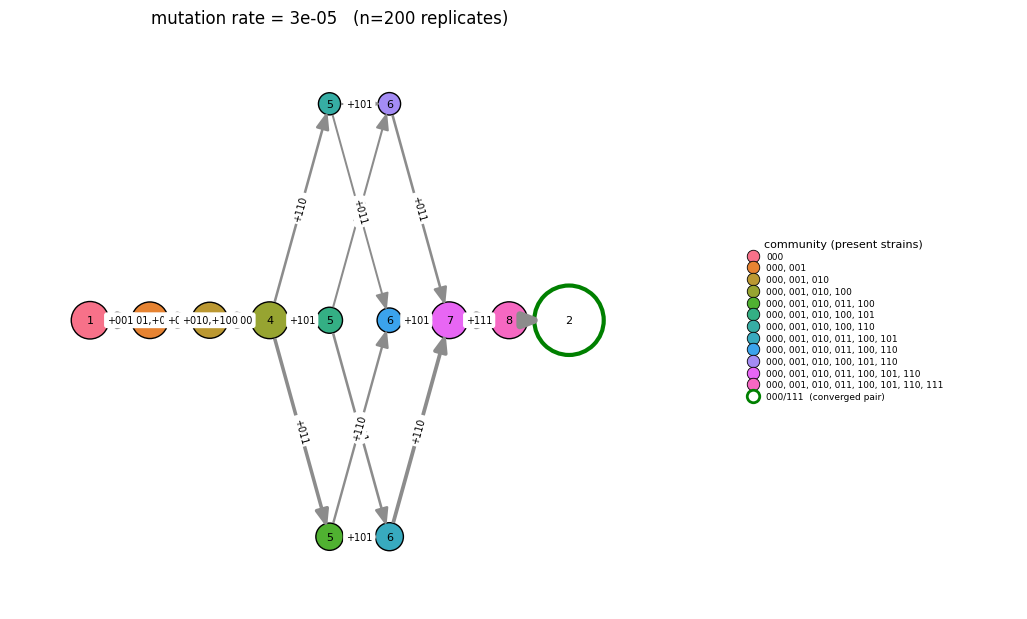

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-05+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-05+ext=.png


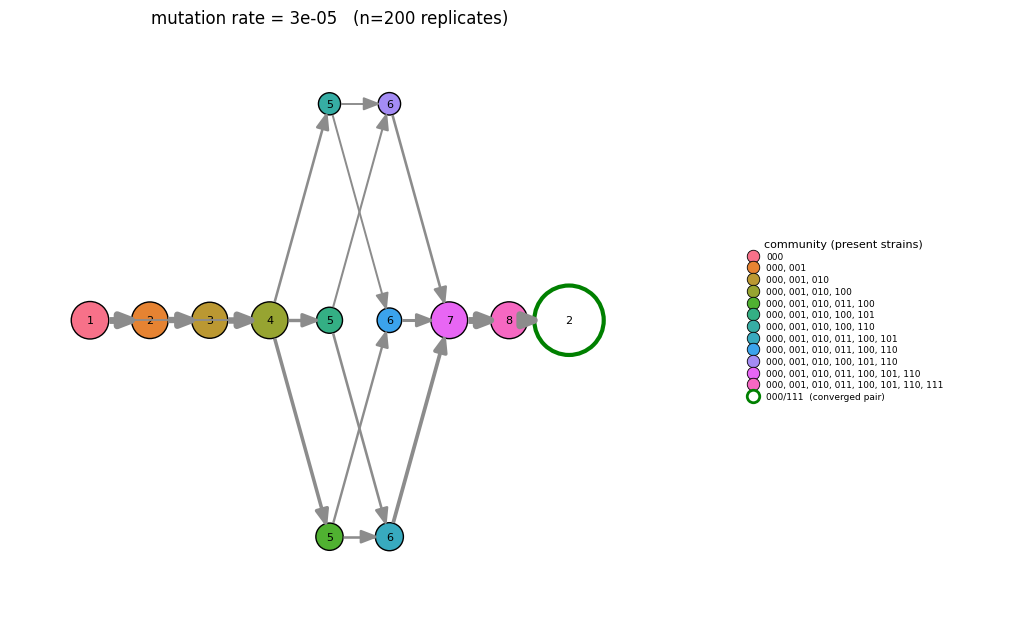

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-04+ext=.png


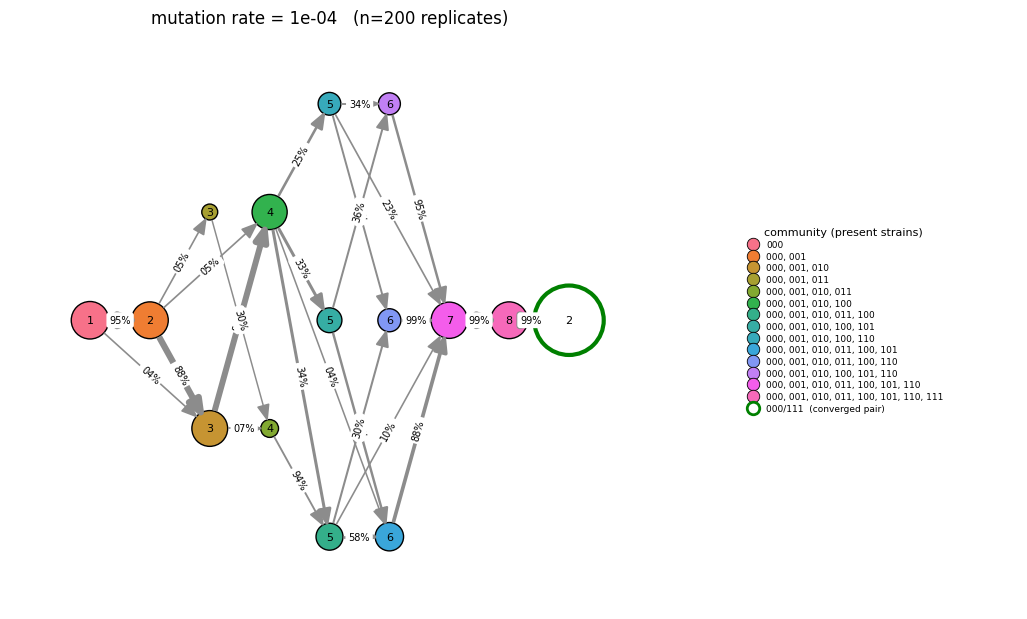

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-04+ext=.png


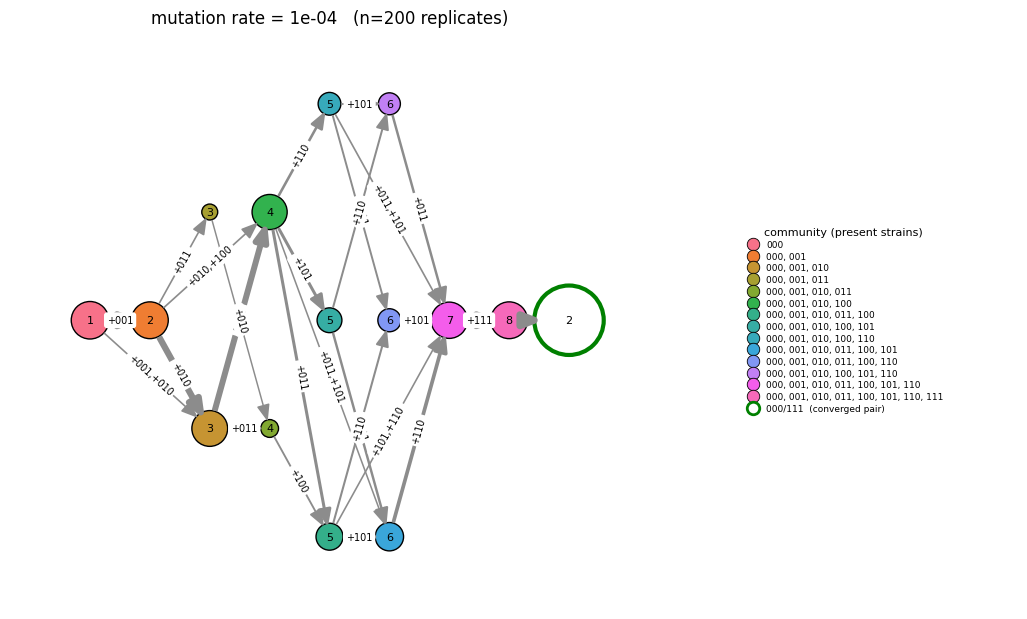

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-04+ext=.png


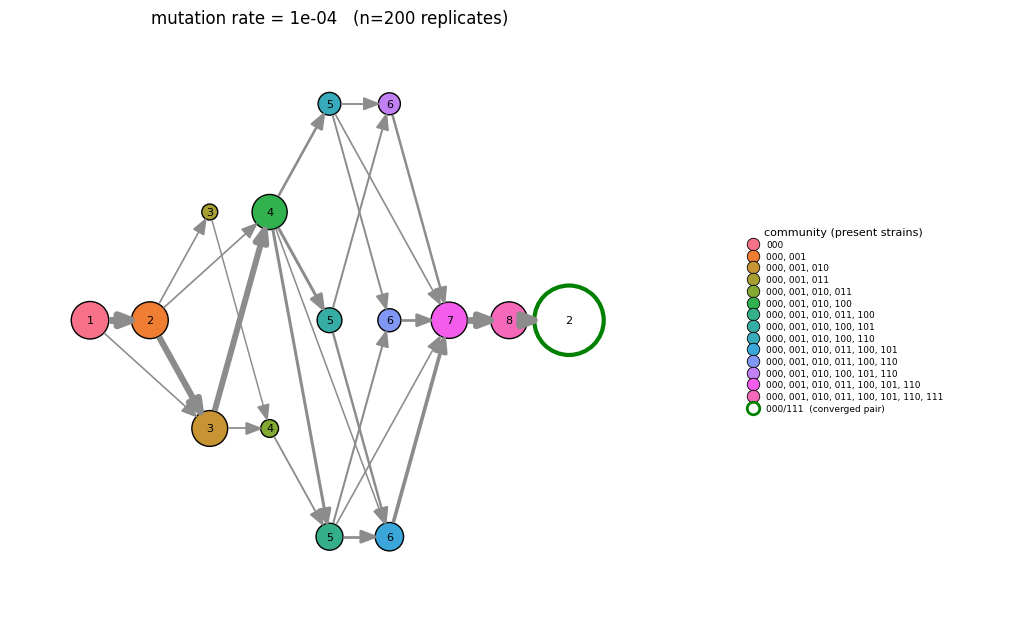

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-04+ext=.png


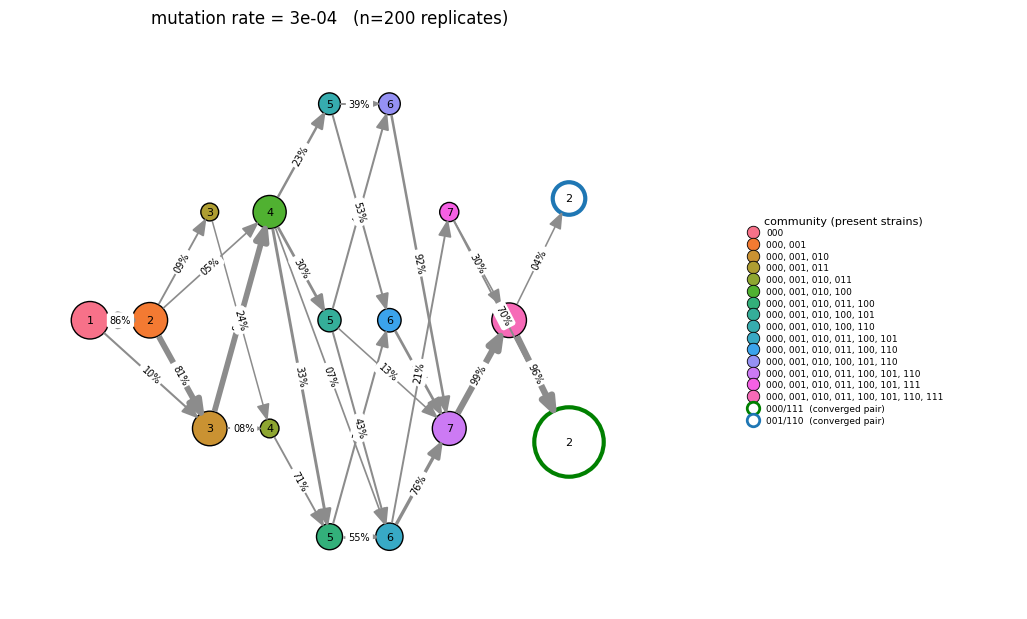

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-04+ext=.png


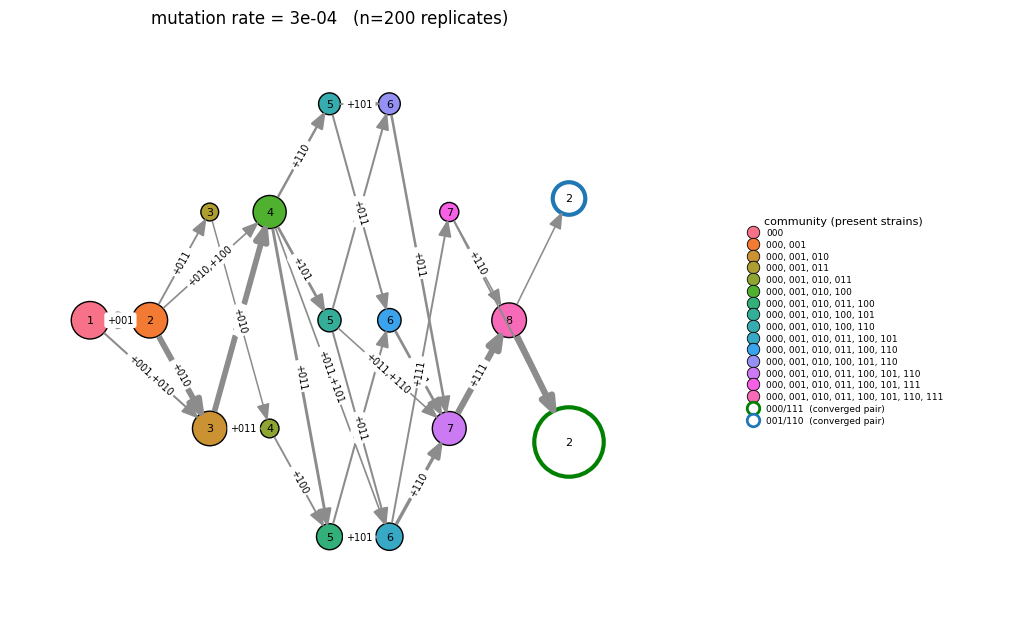

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-04+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-04+ext=.png


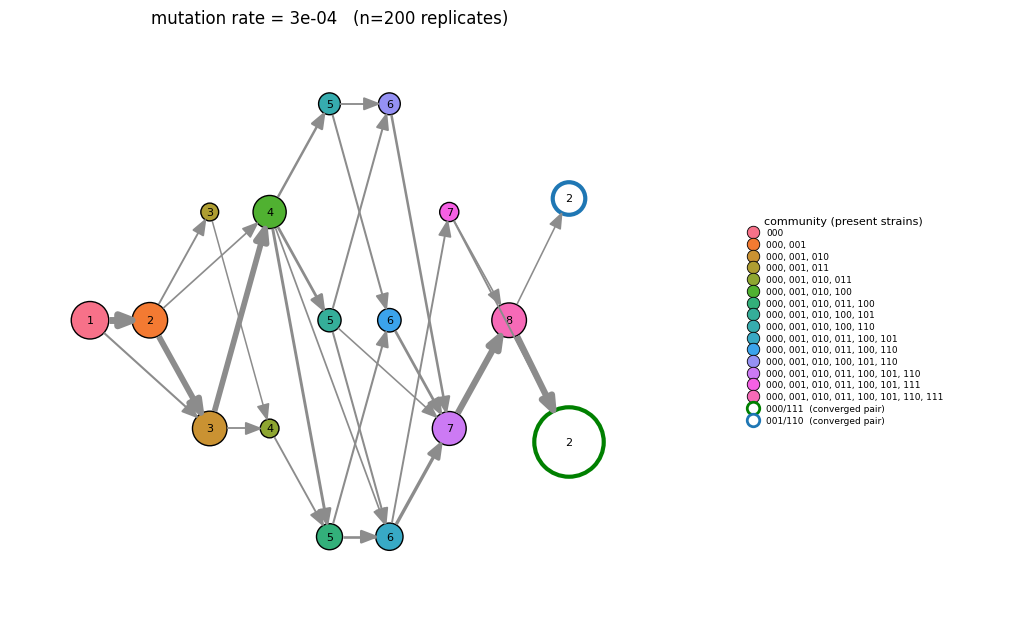

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-03+ext=.png


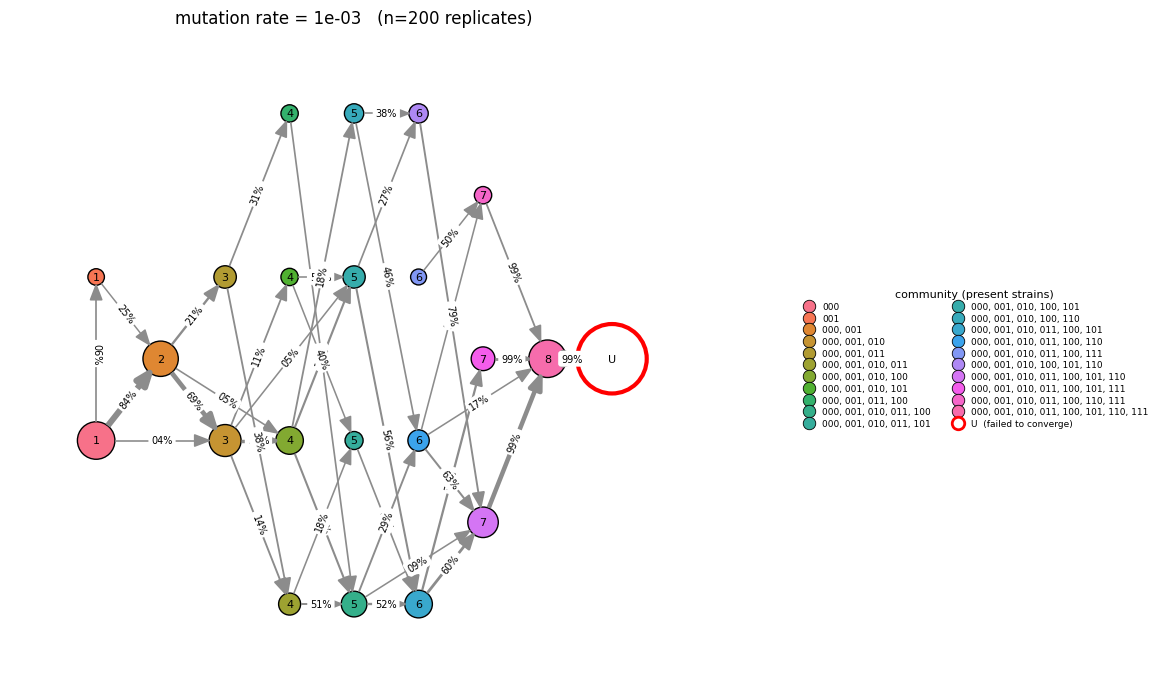

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-03+ext=.png


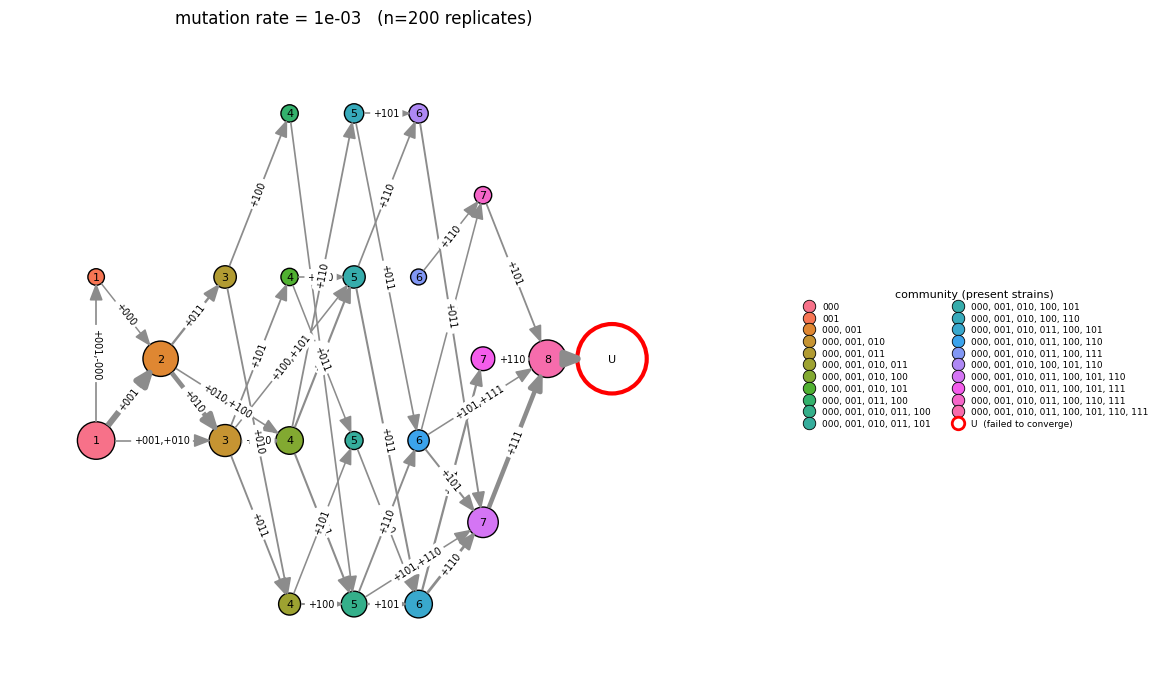

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-03+ext=.png


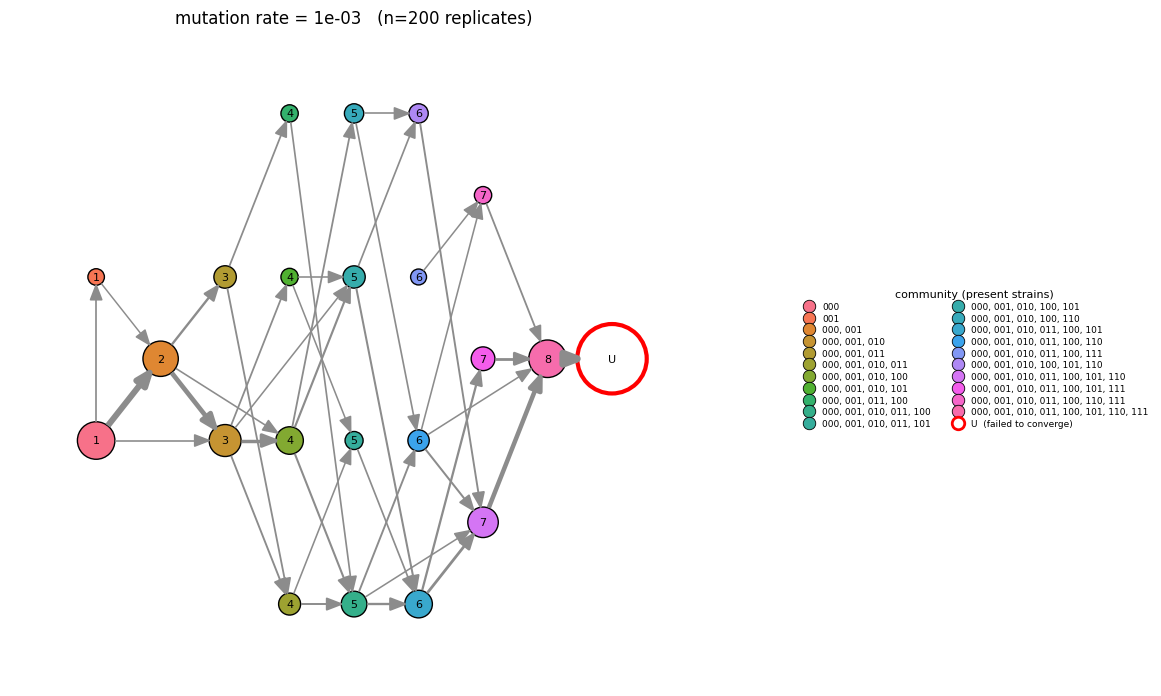

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-03+ext=.png


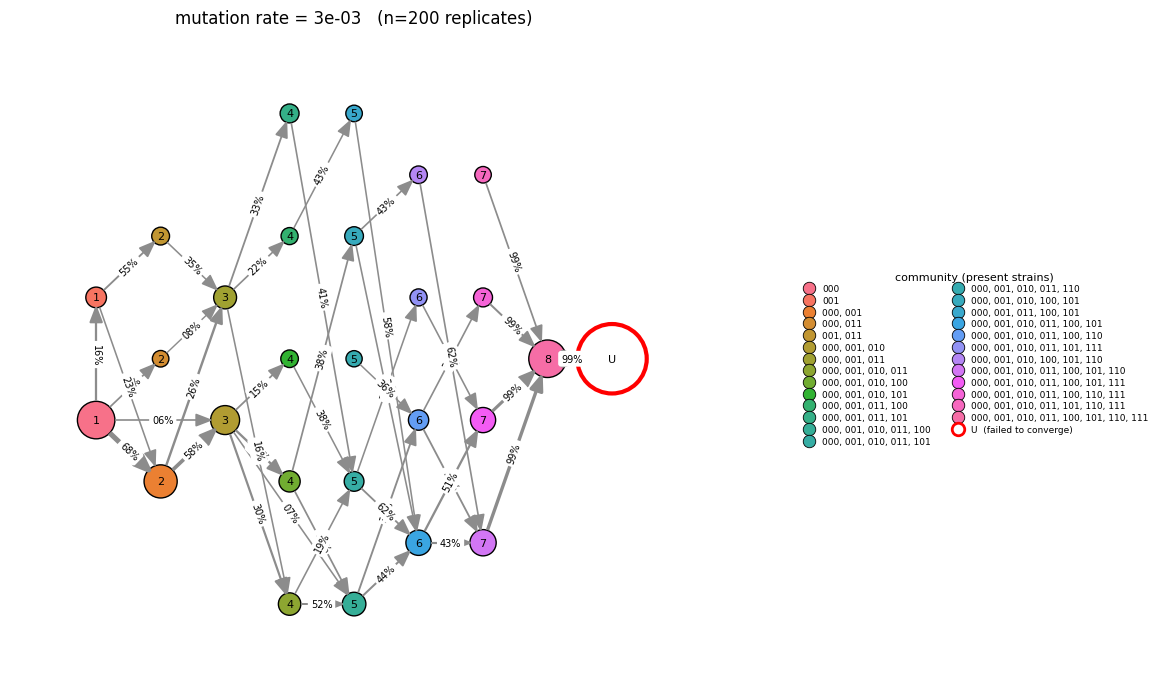

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-03+ext=.png


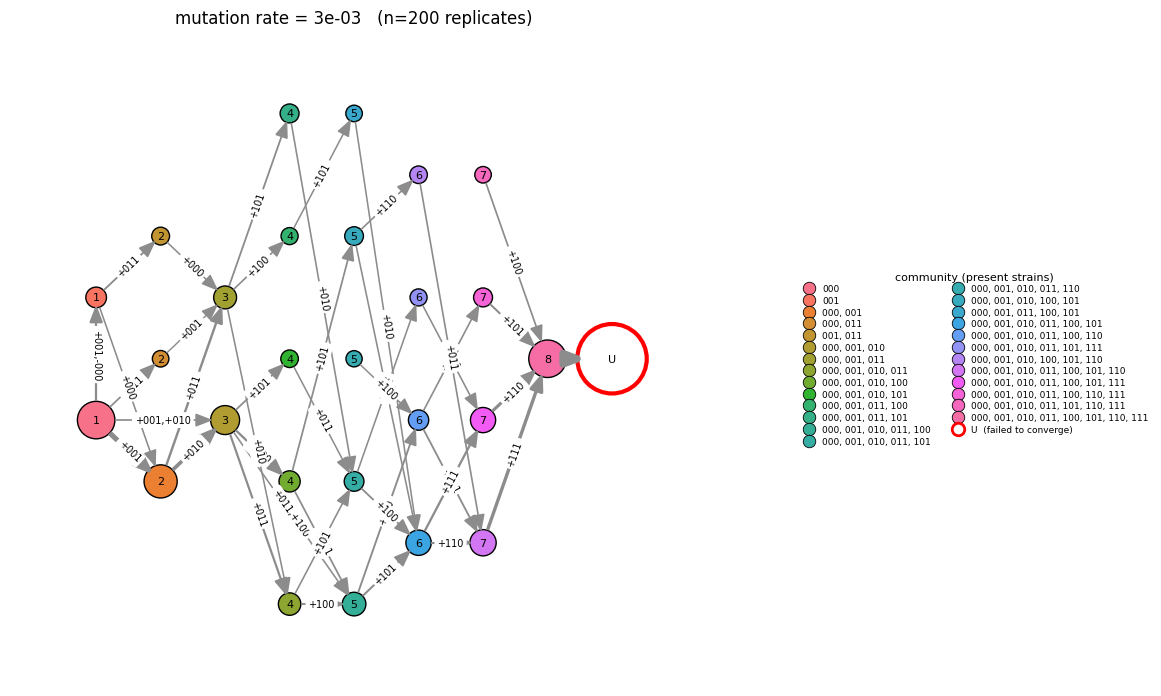

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-03+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-03+ext=.png


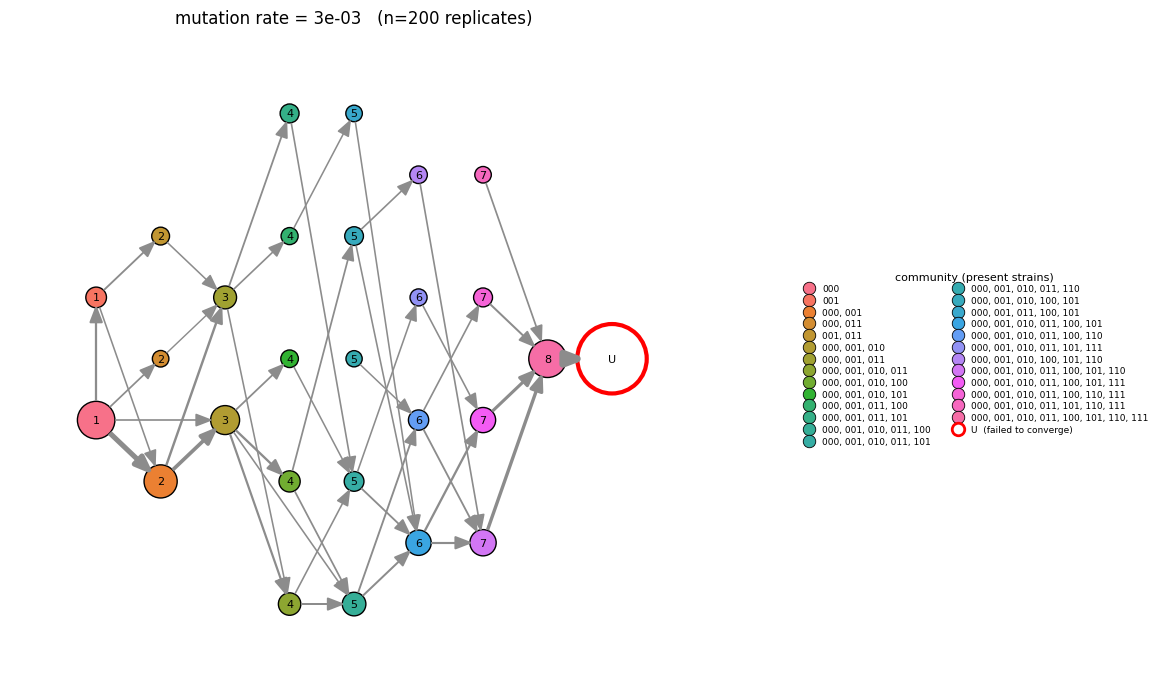

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-02+ext=.png


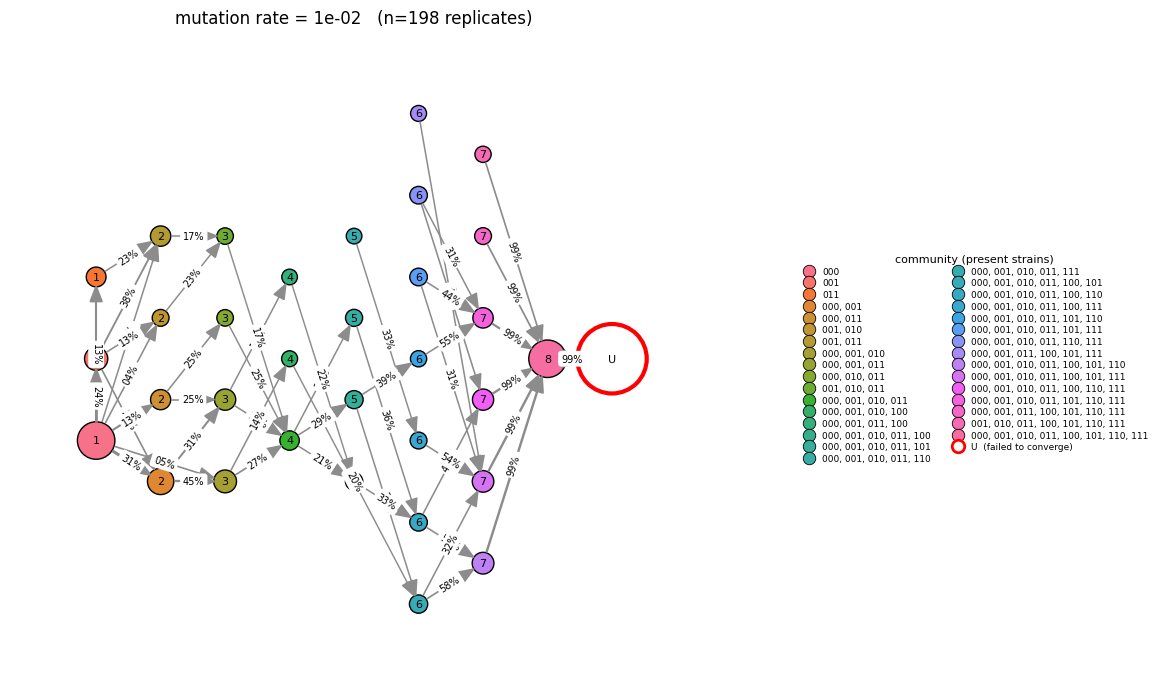

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-02+ext=.png


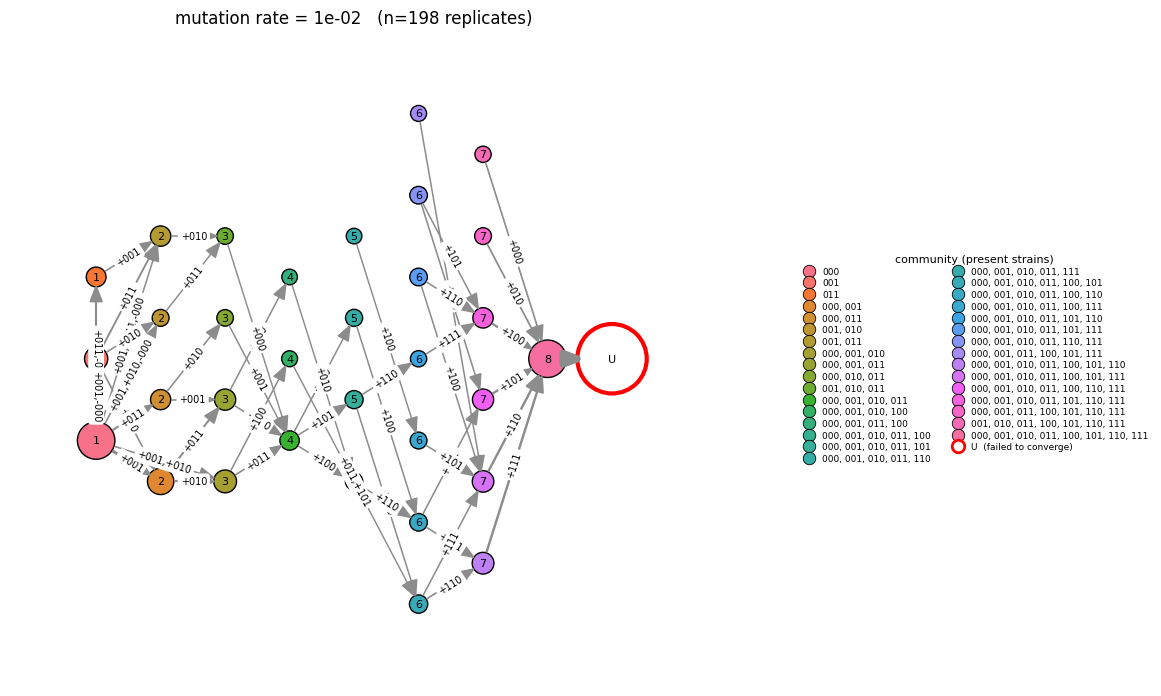

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-02+ext=.png


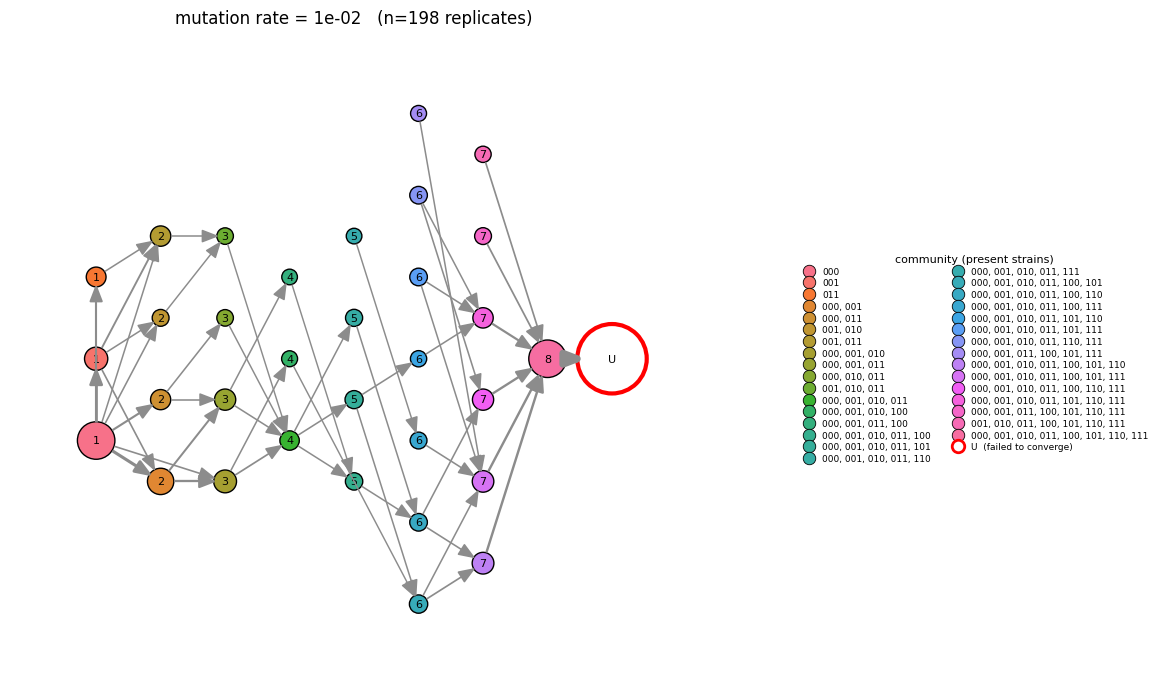

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=3e-02+ext=.png


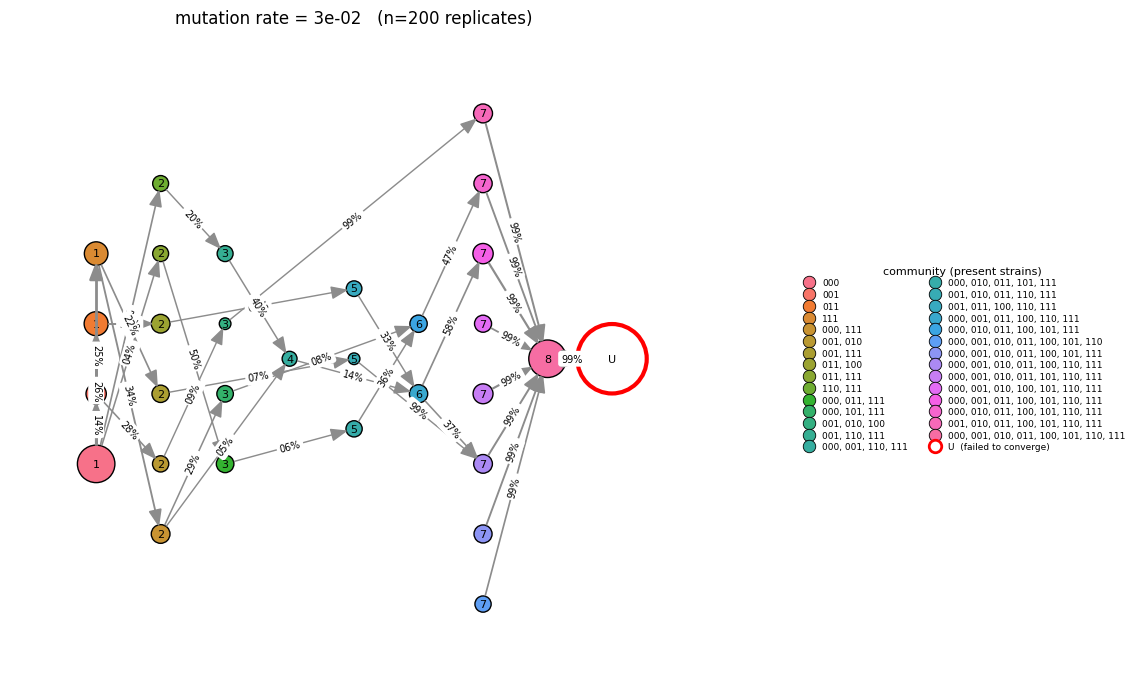

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=3e-02+ext=.png


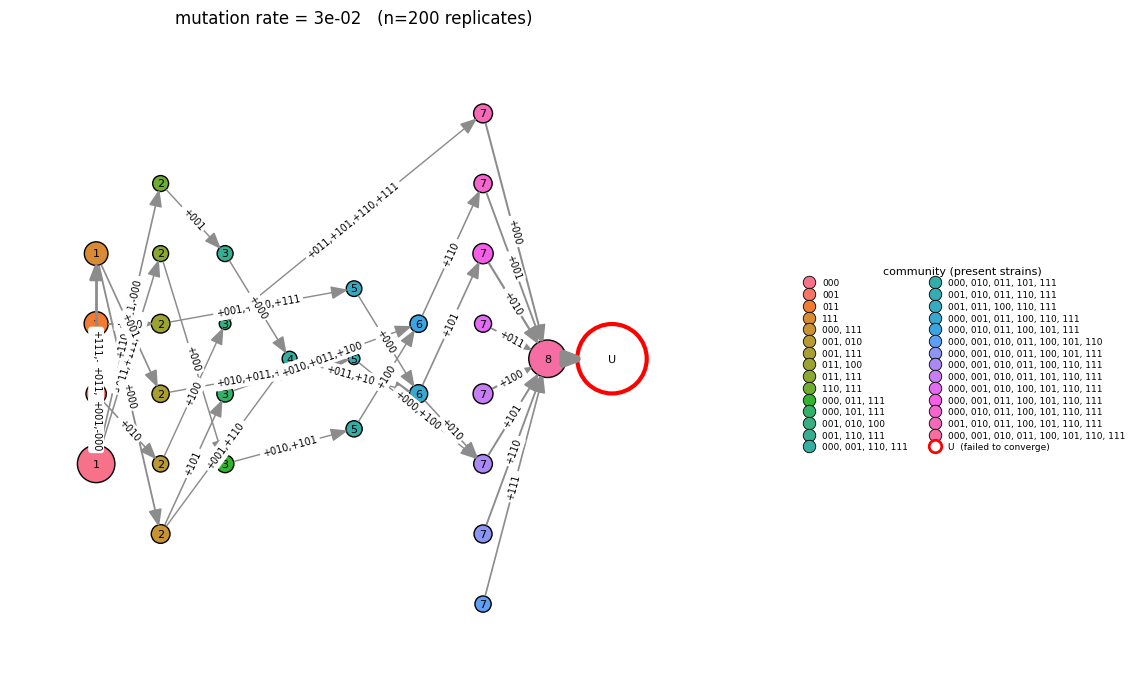

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-02+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=3e-02+ext=.png


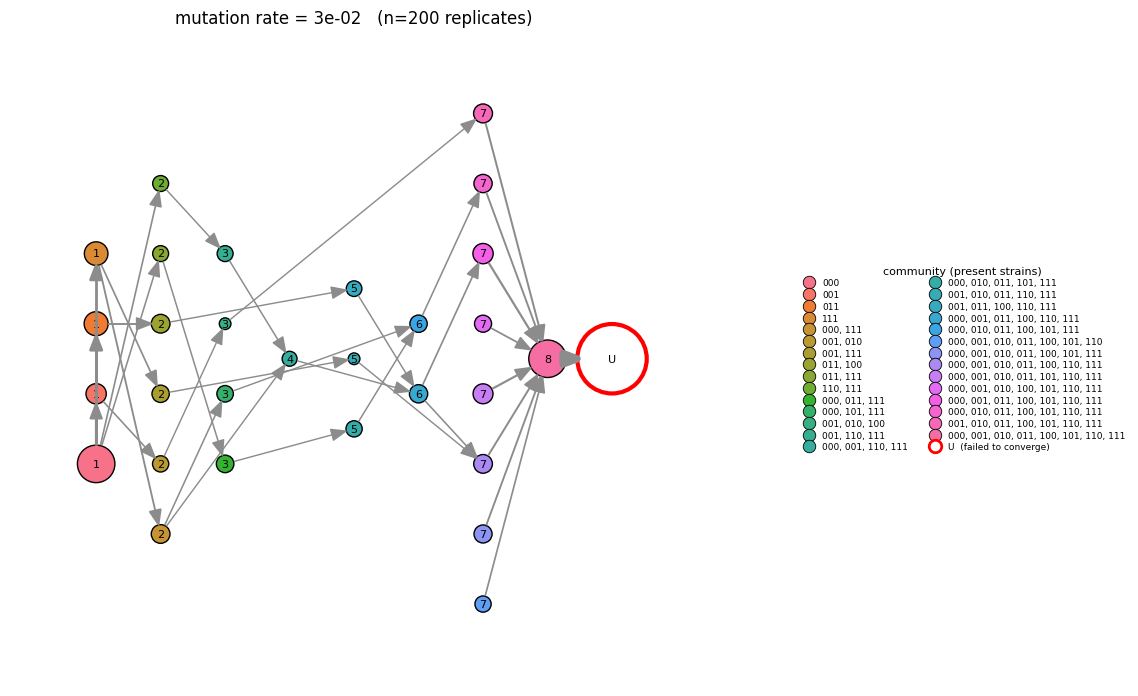

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-01+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=pct+mutation-rate=1e-01+ext=.png


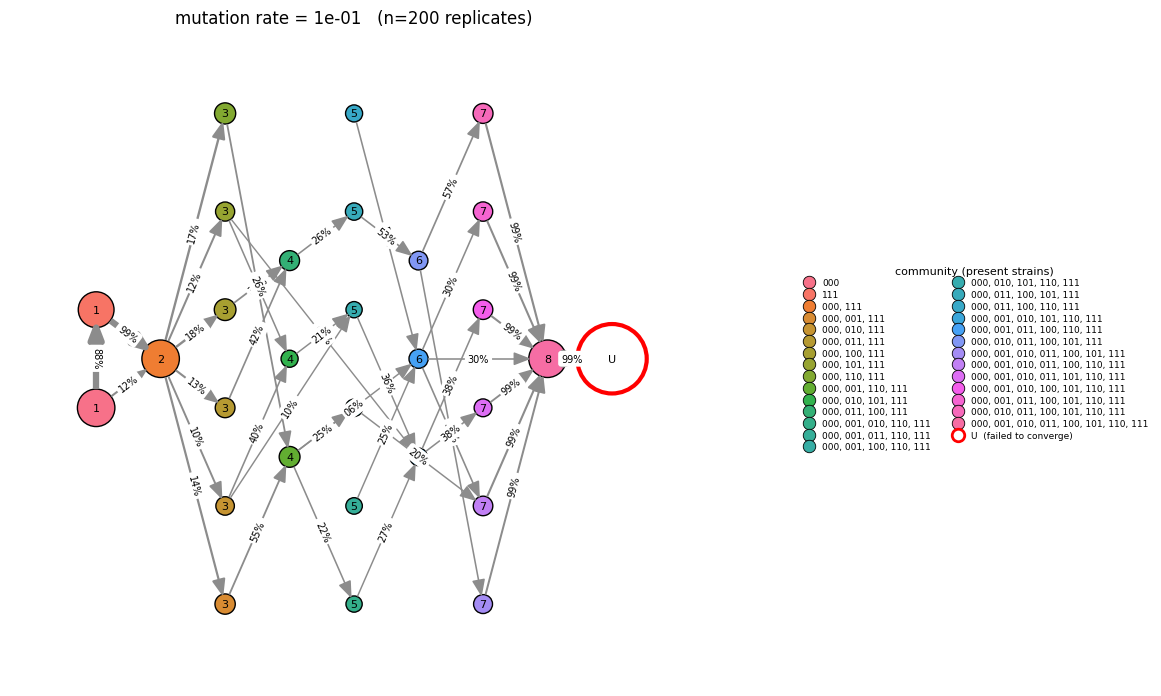

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-01+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=delta+mutation-rate=1e-01+ext=.png


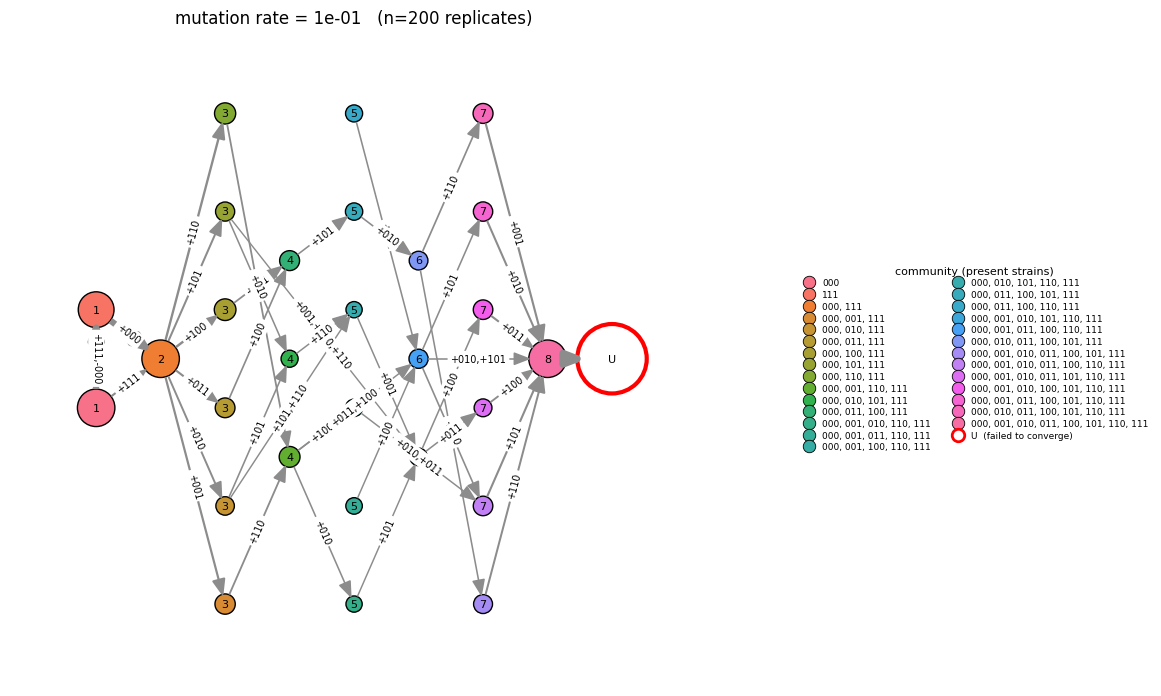

teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-01+ext=.pdf
teeplots/2026-06-24-community-assembly-graph/a=community-assembly-graph+edge-labels=none+mutation-rate=1e-01+ext=.png


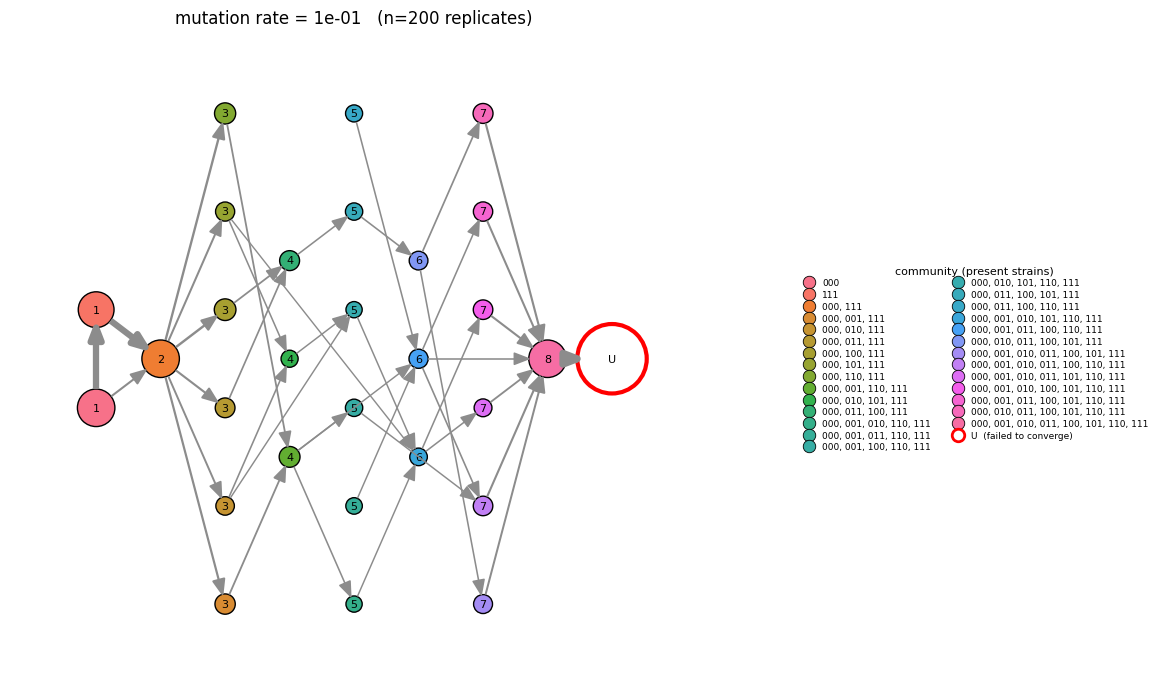

In [ ]:
# Render three versions per mutation rate: edge percentage labels,
# strain-level +/- transition labels, and bare arrows (no labels).
# teeplot_outattrs tags them apart.
for _mu in mutation_rates:
    _bundle = aggregates[_mu]
    _n_nodes = len(_bundle["keep"])
    _wide = _n_nodes > 18

    def _factory(**kwargs):
        fig, (ax, lax) = plt.subplots(
            1, 2, gridspec_kw={"width_ratios": [3, 1.3]}, **kwargs
        )
        return fig, (ax, lax)

    for _tag in ("pct", "delta", "none"):
        with tp.teed(
            _factory,
            figsize=(14 if _wide else 13, 8.5 if _wide else 7.5),
            teeplot_outattrs={
                "a": "community-assembly-graph",
                "mutation-rate": f"{_mu:.0e}",
                "edge-labels": _tag,
            },
            teeplot_outexclude="viz",
            teeplot_show=True,
            teeplot_subdir=pathlib.Path(__file__).stem,
        ) as (fig, (ax, lax)):
            plot_mu(_mu, _bundle, ax, lax, edge_label_mode=_tag)

## Convergence Summary

Fraction of replicates that converge (`D` and complement present and
>50% of cases) versus terminate in `U`, by mutation rate --- the
transition from low-mutation convergence to high-mutation
non-convergence.

In [ ]:
_rows = []
for _mu in mutation_rates:
    _agg = aggregates[_mu]["agg"]
    _n = _agg["n_reps"]
    _u = _agg["end_count"].get("U", 0)
    _rows.append(
        {
            "mutation_rate": f"{_mu:.0e}",
            "n_reps": _n,
            "converged": _n - _u,
            "U (failed)": _u,
            "conv_frac": round((_n - _u) / _n, 3) if _n else 0.0,
        }
    )
_tbl = pd.DataFrame(_rows)
print(_tbl.to_string(index=False))
mo.ui.table(_tbl, selection=None)

mutation_rate  n_reps  converged  U (failed)  conv_frac
        1e-09     200         77         123      0.385
        3e-09     199        183          16      0.920
        1e-08     194        194           0      1.000
        3e-08     200        200           0      1.000
        1e-07     196        196           0      1.000
        3e-07     200        200           0      1.000
        1e-06     200        200           0      1.000
        3e-06     195        195           0      1.000
        1e-05     200        200           0      1.000
        3e-05     200        200           0      1.000
        1e-04     200        200           0      1.000
        3e-04     200        199           1      0.995
        1e-03     200          0         200      0.000
        3e-03     200          0         200      0.000
        1e-02     198          0         198      0.000
        3e-02     200          0         200      0.000
        1e-01     200          0         200    

,mutation_rate,n_reps,converged,U (failed),conv_frac
0,1e-09,200,77,123,0.385
1,3e-09,199,183,16,0.920
2,1e-08,194,194,0,1.000
3,3e-08,200,200,0,1.000
4,1e-07,196,196,0,1.000
...,...,...,...,...,...
12,1e-03,200,0,200,0.000
13,3e-03,200,0,200,0.000
14,1e-02,198,0,198,0.000
15,3e-02,200,0,200,0.000
